# IVE Korea — 리워드 광고 플랫폼: 이상 트래픽 탐지, 매체 운영 및 도메인 최적화

**작성자 개인 기여:** 데이터 통합, 결측치/이상치 처리, 이상 트래픽(어뷰징) 탐지 파이프라인 전체 (Part 1). Part 2(매체 운영 관리)와 Part 3(도메인 최적화)는 팀원이 구축했으며, 파이프라인 연속성을 위해 포함하되 간략히만 문서화합니다.

## 데이터 구조

| 테이블 | 단위(1행 =) | 주요 컬럼 |
|---|---|---|
| `df_master` (광고 마스터) | 광고 캠페인 1건 (`ads_idx`) | 유형, 도메인, 가격, 일정 |
| `df_engagement` (클릭) | 클릭/참여 이벤트 1건 (`click_key`) | 디바이스, IP, 매체, 비용 |
| `df_reward` (전환) | 리워드 지급 이벤트 1건 (`click_key`, engagement의 부분집합) | CTIT, 비용 세부 |
| `df_report` (시간대별 리포트, 1년) | (날짜, 시간, 광고, 매체) 단위 | 클릭/전환/비용 집계 |

`click_key`는 engagement와 reward를 잇는 조인 키입니다. `df_reward`의 모든 `click_key`는 `df_engagement`에 반드시 존재해야 하지만, 역은 성립하지 않습니다(대부분의 클릭은 전환되지 않음).

## 비용 구조 (누가 누구에게 지불하는가)

| 필드 | 의미 |
|---|---|
| `show_cost` / `rpt_time_scost` | 광고주에게 청구되는 금액 |
| `adv_cost` / `rpt_time_acost` | IVE가 실제로 수취하는 금액 |
| `earn_cost` / `rpt_time_earn` | 매체 파트너에게 지급할 금액 |
| `rwd_cost` / `rpt_time_cost` | 사용자에게 지급되는 금액 |

구조상 `show_cost >= adv_cost >= earn_cost >= rwd_cost >= 0`이 항상 성립해야 하며, 이를 위반하는 행은 데이터 무결성 오류로 전처리 단계(Step 2)에서 제거합니다.

## 검증 가설 (Part 1)

- **H1 (속도):** 사람이 물리적으로 불가능한 속도의 전환(거의 0에 가까운 클릭-설치 소요시간)은 자동화된 처리를 시사
- **H2 (디바이스 팜):** 하나의 IP 뒤에 비정상적으로 많은 디바이스가 있으면 에뮬레이터/디바이스 팜 가능성
- **H3 (클릭 팜):** 하나의 IP에서 비정상적으로 많은 클릭이 발생하면 스크립트 기반 반복 참여 가능성
- **H4 (집중도):** H1~H3이 성립한다면 이상 트래픽은 소수 매체·특정 광고 유형에 집중되어야 함
- **H5 (시간 패턴):** 봇 트래픽이라면 사람의 활동 리듬(주간 피크, 평일/주말 차이)을 따르지 않아야 함

각 가설은 아래 단계에서 실제 수치로 검증합니다.

---
# PART 1. 데이터 통합 및 이상 트래픽 탐지

분석 기간: 클릭/전환/마스터 테이블은 **2025-07-26 ~ 2025-08-25** (31일). `df_report`는 1년치(2024-07-27 ~ 2025-08-29)이며, 이후 시계열 검증(Step 13-19)에 사용합니다.

## Step 1. 데이터 로드 및 기본 전처리

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 11,
})
PALETTE = {
    'critical': '#c0392b', 'risky': '#e67e22', 'warning': '#f1c40f', 'normal': '#2ecc71',
    'outlier': '#c0392b', 'abusing': '#e67e22', 'non_rewarded': '#95a5a6', 'clean_normal': '#2ecc71',
}

df_master    = pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/광고 목록_도메인 라벨링_결측치처리.csv', low_memory=False)
df_reward    = pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/IVE_광고적립_all.csv', low_memory=False)
df_engagement= pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/IVE_광고참여정보_all.csv', low_memory=False)
df_report    = pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/아이브시간대별광고리포트_1년치_all.csv', low_memory=False)

In [13]:
ANALYSIS_START = pd.to_datetime('2025-07-26')
ANALYSIS_END   = pd.to_datetime('2025-08-25')

# 종료일 미정 센티널 값("9999-12-31") 처리: 전체 광고의 96.7%가 해당.
# 날짜 파싱 전, 문자열 단계에서 실제 처리 가능한 날짜로 치환 (파싱 후 처리 시 일부 pandas버전에서 NaT로 조용히 깨지는 것을 방지)
ANALYSIS_LATEST_DATE = '2025-08-29'
edate_raw = df_master['ads_edate'].astype(str)
is_sentinel = edate_raw.str.contains('9999', na=False)
df_master['ads_edate'] = edate_raw.where(~is_sentinel, ANALYSIS_LATEST_DATE)
print(f"ads_edate 센티널 치환: {is_sentinel.sum():,} / {len(df_master):,}건")

for col in ['regdate', 'ads_sdate', 'ads_edate']:
    df_master[col] = pd.to_datetime(df_master[col], errors='coerce')
print(f"ads_edate 파싱 실패(NaT): {df_master['ads_edate'].isna().sum()}건 -- 결측/오류")

AD_TYPE_MAP = {
    1: 'install', 2: 'launch', 3: 'participation', 4: 'click_type',
    5: 'facebook', 6: 'twitter', 7: 'instagram', 8: 'display',
    9: 'quest', 10: 'youtube', 11: 'naver', 12: 'CPS(purchase)'
}
DOMAIN_MAP = {1: 'entertainment', 2: 'finance', 3: 'lifestyle', 4: 'commerce', 5: 'other'}

ads_edate 센티널 치환: 430,501 / 445,260건
ads_edate 파싱 실패(NaT): 14759건 -- 결측/오류


### 1a. 도메인 라벨 보정

초기 도메인 라벨은 규칙 기반 + Gemini LLM 하이브리드 분류기로 생성했습니다(세부 방법은 README 참고). 100건 무작위 표본 검수(94% 일치) 결과 약 6~7건의 명확한 오분류를 발견했으며, 대부분 `other`(분류기가 확신하지 못한 것들을 모아두는 버킷)에 집중되어 있었고 게임 1건이 `commerce`로 잘못 분류되어 있었습니다.

이 보정은 `df_master`에서 복사/조인이 일어나기 전에 실행되므로, 이후 모든 단계(리스크 스코어링, 매체 KPI, 도메인 최적화)가 동일하게 보정된 라벨을 사용합니다.

In [14]:
domain_label_fixes = {
    1: ['원스토어'],  # 원스토어 등록 모바일 게임이 commerce로 오분류 -> entertainment로 수정
    4: [
        '에어매쉬토퍼', '시어서커 패드', '바디필로우', '마사지건', '다이어트',
        '액정보호필름', '타공기', '아쿠아디지오', '아르마니', '윈드배너',
    ],  # 실물/뷰티 제품이 lifestyle/other로 오분류 -> commerce로 수정
}
for target_label, keywords in domain_label_fixes.items():
    for kw in keywords:
        mask = df_master['ads_name'].str.contains(kw, na=False)
        n = int(mask.sum())
        if n > 0:
            df_master.loc[mask, 'domain_label'] = target_label
            print(f"'{kw}' {n}건 매칭 -> domain_label {target_label}로 재분류")

'원스토어' 623건 매칭 -> domain_label 1로 재분류
'에어매쉬토퍼' 2건 매칭 -> domain_label 4로 재분류
'시어서커 패드' 2건 매칭 -> domain_label 4로 재분류
'바디필로우' 129건 매칭 -> domain_label 4로 재분류
'마사지건' 12건 매칭 -> domain_label 4로 재분류
'다이어트' 365건 매칭 -> domain_label 4로 재분류
'액정보호필름' 51건 매칭 -> domain_label 4로 재분류
'타공기' 11건 매칭 -> domain_label 4로 재분류
'아쿠아디지오' 8건 매칭 -> domain_label 4로 재분류
'아르마니' 11건 매칭 -> domain_label 4로 재분류
'윈드배너' 8건 매칭 -> domain_label 4로 재분류


> **알려진 한계:** 100건 표본 검수에서 발견된 오류에 대한 타겟 보정이며, 전수 재라벨링이 아닙니다. 특히 `other` 도메인은 실제 예산 의사결정에 사용하기 전 전수 검수가 필요합니다.

In [15]:
# df_master2: 도메인 보정이 끝난 카탈로그의 전체 행 복사본. 
# Step 2의 비용 이상치 필터 적용 이전 시점의 복사본으로, CTIT 중앙값 계산이나 df_integrated/df_report 조인 등 전체 광고 행이 필요한 곳에 사용
df_master2 = df_master.copy()
df_master2['ads_type_name'] = df_master2['ads_type'].map(AD_TYPE_MAP)
df_master2['domain_name']   = df_master2['domain_label'].map(DOMAIN_MAP)

df_reward['advid'] = df_reward['advid'].fillna('Unknown')

df_engagement = (
    df_engagement
    .drop(columns=['carrier'])       
    .assign(network=lambda x: x['network'].fillna('Unknown'))
    .dropna(subset=['user_ip'])       
    .reset_index(drop=True)
)

## Step 2. 비용 구조 이상치 제거 — 데이터 품질 점검 #1

**규칙:** 모든 비용 레코드에서 `광고주 지불액 >= IVE 수취액 >= 매체 지급액 >= 사용자 리워드 >= 0`이 성립해야 합니다(리워드 광고 비즈니스의 실제 회계 항등식). 이를 위반하거나 있어서는 안 될 곳에서 정확히 0인 행은 "어뷰징"이 아니라 데이터 오류이므로 분석 전에 제거합니다.

In [16]:
before_master = len(df_master)
df_master = df_master[
    (df_master['ads_contract_price'] >= df_master['ads_reward_price']) &
    (df_master['ads_contract_price'] > 0) &
    (df_master['ads_reward_price']   >= 0)
].reset_index(drop=True)

before_engagement = len(df_engagement)
df_engagement = df_engagement[
    (df_engagement['adv_price']      >= df_engagement['contract_price']) &
    (df_engagement['contract_price'] >= df_engagement['media_price']) &
    (df_engagement['media_price']    >= df_engagement['reward_price']) &
    (df_engagement[['adv_price', 'contract_price', 'media_price']].min(axis=1) > 0) &
    (df_engagement['reward_price'] >= 0)
].reset_index(drop=True)

before_reward = len(df_reward)
df_reward = df_reward[
    (df_reward['show_cost'] >= df_reward['adv_cost']) &
    (df_reward['adv_cost']  >= df_reward['earn_cost']) &
    (df_reward['earn_cost'] >= df_reward['rwd_cost']) &
    (df_reward[['show_cost', 'adv_cost', 'earn_cost']].min(axis=1) > 0) &
    (df_reward['rwd_cost'] >= 0)
].reset_index(drop=True)

# 매칭되는 engagement 행이 없는 reward 행도 무결성 오류
valid_click_keys = set(df_engagement['click_key'])
before_orphan = len(df_reward)
df_reward = df_reward[df_reward['click_key'].isin(valid_click_keys)].reset_index(drop=True)

print("[데이터 품질 점검 #1 — 비용 구조 무결성]")
print(f"  광고 카탈로그: {before_master:>10,} ->{len(df_master):>10,}  ({before_master-len(df_master):>7,}건 제거, "
      f"{(before_master-len(df_master))/before_master*100:.2f}%)")
print(f"  engagement: {before_engagement:>10,} -> {len(df_engagement):>10,}  "
      f"({before_engagement-len(df_engagement):>7,}건 제거, "
      f"{(before_engagement-len(df_engagement))/before_engagement*100:.2f}%)")
print(f"  reward: {before_reward:>10,} -> {len(df_reward):>10,}  ({before_reward-len(df_reward):>7,}건 제거, "
      f"{(before_reward-len(df_reward))/before_reward*100:.2f}%)")
print(f"  매칭 클릭 없는 reward: {before_orphan-len(df_reward)}건")

# 병합 무결성 가드 -- 1,600만 행 규모 병합에서 조용한 행 폭증을 방지
assert df_reward['click_key'].duplicated().sum() == 0, "df_reward의 click_key가 유일하지 않음"
print("  병합 무결성 검증 통과: reward.click_key 유일성 확인 (1:1 병합에 필요)")

[데이터 품질 점검 #1 — 비용 구조 무결성]
  광고 카탈로그:    445,260 ->   444,693  (    567건 제거, 0.13%)
  engagement: 16,854,856 -> 16,831,054  ( 23,802건 제거, 0.14%)
  reward:  1,475,031 ->  1,470,533  (  4,498건 제거, 0.30%)
  매칭 클릭 없는 reward: 81건
  병합 무결성 검증 통과: reward.click_key 유일성 확인 (1:1 병합에 필요)


## Step 3. 피처 엔지니어링 — 3가지 이상 신호 (H1, H2, H3 검증)

In [17]:
# H1: 클릭-설치 소요시간 (CTIT)
# 광고 유형별 중앙값 CTIT의 약 10% 미만인 전환은 통계적 극단치로 처리(이 플랫폼 자체 분포 기준의 통계적 휴리스틱이며, 사람의 물리적 반응속도 한계에 대한 주장은 아님)
# click_type(=4)은 CTIT==0이 정상이 아니라 오류 신호이므로 별도 처리

df_reward['is_rewarded_flag'] = 1 
ctit_tmp = df_reward[['ads_idx', 'ctit']].merge(
    df_master2[['ads_idx', 'ads_type']], on='ads_idx', how='left', validate='many_to_one'
)
ctit_threshold_by_type = (
    ctit_tmp[ctit_tmp['ads_type'] != 4]
    .groupby('ads_type')['ctit'].median() * 0.1
).to_dict()

ctit_tmp['threshold'] = ctit_tmp['ads_type'].map(ctit_threshold_by_type)
is_ctit_error = (
    ((ctit_tmp['ads_type'] == 4) & (ctit_tmp['ctit'] == 0)) |
    ((ctit_tmp['ads_type'] != 4) & (ctit_tmp['ctit'] < ctit_tmp['threshold']))
)
df_reward['ctit_error'] = np.where(is_ctit_error.values, 'Y', 'N')

# H2 / H3: 디바이스 팜 & 클릭 팜 신호
# device_count = 하나의 (매체, IP) 쌍에서 관측된 고유 디바이스 수
# click_count  = 하나의 (매체, IP) 쌍의 총 클릭 수
ip_stats = (
    df_engagement
    .groupby(['mda_idx', 'user_ip'])
    .agg(device_count=('dvc_idx', 'nunique'), click_count=('click_key', 'count'))
    .reset_index()
)
print(f"IP 단위 통계 행 수: {len(ip_stats):,}")

IP 단위 통계 행 수: 962,174


## Step 4. 통합 클릭 단위 테이블 구축

In [18]:
# 병합 전 무결성 가드 -- validate=로 조인 키 중복 시 조용한 행 폭증 대신 에러 발생
assert df_master2['ads_idx'].duplicated().sum() == 0, "광고 카탈로그의 ads_idx가 유일하지 않음"

df_integrated = (
    df_engagement
    .merge(df_reward, on = 'click_key', how = 'left', validate = 'one_to_one', suffixes = ('', '_reward'))
    .merge(df_master2, on = 'ads_idx', how = 'left', validate = 'many_to_one', suffixes = ('', '_master'))
    .merge(ip_stats, on = ['mda_idx', 'user_ip'],  how = 'left', validate = 'many_to_one')
)

df_integrated['is_rewarded'] = df_integrated['is_rewarded_flag'].fillna(0).astype(int)
df_integrated['ctit_missing'] = df_integrated['is_rewarded'].eq(1) & df_integrated['ctit'].isna()
print(f"df_integrated 행 수: {len(df_integrated):,}  |  is_rewarded=1(전환): {df_integrated['is_rewarded'].sum():,}  "
      f"|  전환O·ctit결측: {df_integrated['ctit_missing'].sum()}")

df_integrated 행 수: 16,831,054  |  is_rewarded=1(전환): 1,470,533  |  전환O·ctit결측: 0


## Step 5. 행 단위 분류 (H2, H3 정량 검증)

`device_count`, `click_count`의 등급 기준 (매체×IP 쌍 전체 대비 백분위수):

| 등급 | 기준 |
|---|---|
| outlier | 상위 0.1% |
| risky | 상위 1.0% (outlier 제외) |
| warning | 상위 5.0% (risky/outlier 제외) |
| normal | 나머지 95% |

`row_label`(클릭별 최종 판정) — 이 파이프라인은 독립적으로 검증된 정답 라벨 없이 플랫폼 자체 트래픽 대비 통계적 백분위수 기준만 사용합니다. 따라서 `outlier`는 **이 플랫폼 자체 분포 대비 통계적 극단치**를 의미하며, 법적·계약상 부정 판정이 아닙니다.

- **non_rewarded** — 전환되지 않은 클릭
- **outlier** — 3개 지표 중 하나라도 0.1% 극단 구간 -> 고신뢰 이상치, 정산 차감 후보
- **abusing** — 극단은 아니지만 하나 이상 지표가 risky/warning 구간 -> 모니터링 대상
- **normal** — 모든 지표 정상

In [19]:
d_crit = ip_stats['device_count'].quantile(0.999)
d_dang = ip_stats['device_count'].quantile(0.99)
d_warn = max(2, ip_stats['device_count'].quantile(0.95))
c_crit = ip_stats['click_count'].quantile(0.999)
c_dang = ip_stats['click_count'].quantile(0.99)
c_warn = ip_stats['click_count'].quantile(0.95)

print(f"[디바이스 수 임계값]  normal<={d_warn:.0f}  warning~{d_dang:.0f}  risky~{d_crit:.0f}  outlier>{d_crit:.0f}")
print(f"[클릭 수 임계값]      normal<={c_warn:.0f}  warning~{c_dang:.0f}  risky~{c_crit:.0f}  outlier>{c_crit:.0f}")

ip_stats['device_grade'] = np.select(
    [ip_stats['device_count'] <= d_warn, ip_stats['device_count'] <= d_dang, ip_stats['device_count'] <= d_crit],
    ['normal', 'warning', 'risky'], default='outlier')
ip_stats['click_grade'] = np.select(
    [ip_stats['click_count'] <= c_warn, ip_stats['click_count'] <= c_dang, ip_stats['click_count'] <= c_crit],
    ['normal', 'warning', 'risky'], default='outlier')

df_integrated = df_integrated.merge(
    ip_stats[['mda_idx', 'user_ip', 'device_grade', 'click_grade']],
    on=['mda_idx', 'user_ip'], how='left', validate='many_to_one'
)
df_integrated['device_grade'] = df_integrated['device_grade'].fillna('normal')
df_integrated['click_grade']  = df_integrated['click_grade'].fillna('normal')

# ctit_grade는 non_rewarded/outlier/normal 3가지 값만 가짐 -- device/click count와 달리
# 중간(risky/warning) 구간이 없음: 개별 클릭의 CTIT는 극단 속도 임계값을 넘거나 안 넘거나 둘 중 하나
df_integrated['ctit_grade'] = np.select(
    [df_integrated['ctit_error'].isna(), df_integrated['ctit_error'] == 'Y', df_integrated['ctit_error'] == 'N'],
    ['non_rewarded', 'outlier', 'normal'], default='non_rewarded')

is_outlier = ((df_integrated['ctit_grade']=='outlier') | (df_integrated['device_grade']=='outlier')
              | (df_integrated['click_grade']=='outlier'))
# device_grade/click_grade는 전환 여부와 무관하게 적용되는 IP 단위 속성이므로
# abusing은 non_rewarded보다 먼저 체크해야 함 -- 순서를 바꾸면 전환되지 않은 이상 클릭이
# 조용히 non_rewarded에 묻혀버림
is_abusing = ((df_integrated['device_grade'].isin(['warning','risky'])) |
              (df_integrated['click_grade'].isin(['warning','risky'])))
is_non_rewarded = df_integrated['is_rewarded'] == 0

df_integrated['row_label'] = np.select(
    [is_outlier, is_abusing, is_non_rewarded],
    ['outlier', 'abusing', 'non_rewarded'], default='normal'
)
print(f"\n[row_label 분포]\n{df_integrated['row_label'].value_counts()}")

[디바이스 수 임계값]  normal<=3  warning~6  risky~88  outlier>88
[클릭 수 임계값]      normal<=37  warning~258  risky~934  outlier>934

[row_label 분포]
row_label
abusing         7782515
outlier         6387902
non_rewarded    1849072
normal           811565
Name: count, dtype: int64


**H2/H3 확인:** 0.1% 극단 임계값이 단일 IP 기준 디바이스 88대, 클릭 934건에서 형성됨 — 정상적으로 설명 불가능한 수치입니다. 전체 클릭의 38%(639만 건)가 고신뢰 이상치(`outlier`)이며, 46%(778만 건)가 추가로 모니터링 대상(`abusing`)입니다. 명확히 클린한 클릭은 4.8%뿐입니다.

/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1999717379.py:20: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1999717379.py:20: UserWarning: Glyph 47533 (\N{HANGUL SYLLABLE RIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1999717379.py:20: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1999717379.py:20: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1999717379.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipyker

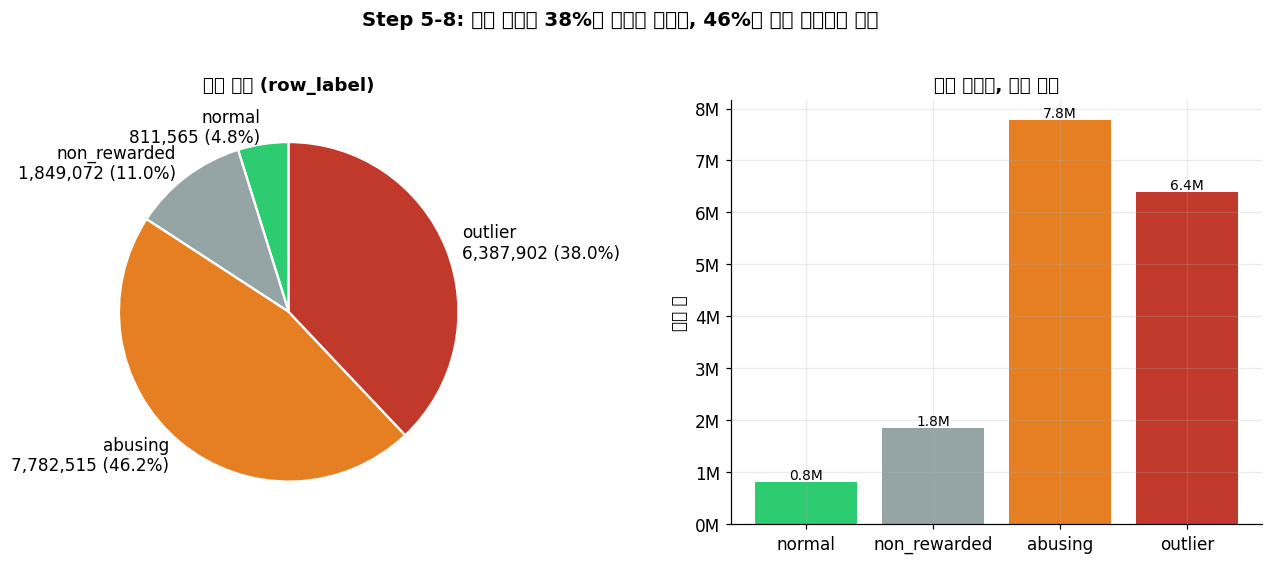

In [20]:
order = ['normal', 'non_rewarded', 'abusing', 'outlier']
counts = df_integrated['row_label'].value_counts().reindex(order)
colors = [PALETTE[c] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(counts, labels=[f"{k}\n{v:,} ({v/counts.sum()*100:.1f}%)" for k, v in counts.items()],
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('클릭 분류 (row_label)', fontsize=12, fontweight='bold')

bars = axes[1].bar(order, counts.values, color=colors)
axes[1].set_ylabel('클릭 수')
axes[1].set_title('동일 데이터, 건수 기준', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x() + b.get_width()/2, v, f'{v/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

plt.suptitle('Step 5-8: 전체 클릭의 38%가 고신뢰 이상치, 46%는 추가 모니터링 대상',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 6. 매체 단위 리스크 스코어링

In [21]:
mda_score = (
    df_integrated.groupby('mda_idx')
    .agg(
        extreme_ratio=('row_label', lambda x: (x=='outlier').mean()),
        abusing_ratio=('row_label', lambda x: (x=='abusing').mean()),
        total_clicks=('click_key','count')
    ).reset_index()
)
mda_score['Risk_Label'] = np.select(
    [mda_score['extreme_ratio'] >= 0.30,
     (mda_score['extreme_ratio'] >= 0.10) | (mda_score['abusing_ratio'] >= 0.50),
     (mda_score['extreme_ratio'] >= 0.03) | (mda_score['abusing_ratio'] >= 0.20)],
    ['critical', 'risky', 'warning'], default='normal'
)
print(f"[매체 {len(mda_score)}개 대상 Risk_Label 분포]")
print(mda_score['Risk_Label'].value_counts())

[매체 189개 대상 Risk_Label 분포]
Risk_Label
normal      135
warning      35
risky        12
critical      7
Name: count, dtype: int64


## Step 7. 매체 리스크를 클릭 단위 테이블에 결합

In [22]:
df_integrated = df_integrated.merge(
    mda_score[['mda_idx','Risk_Label','extreme_ratio','abusing_ratio']], on='mda_idx', how='left'
)
print(pd.crosstab(df_integrated['row_label'], df_integrated['Risk_Label']))

Risk_Label    critical  normal  risky  warning
row_label                                     
abusing        7468347   22316  49153   242699
non_rewarded    793817  396649  29294   629312
normal            6600  322345   6947   475673
outlier        6324546    2000  24550    36806


## Step 8. 손실 정량화 — 데이터 품질 점검 #2

비용은 클릭이 실제로 전환됐을 때만 청구됩니다(`is_rewarded==1`); 비전환 클릭은 구조적으로 `show_cost=0`입니다. 따라서 노출 금액은 전환된 부분집합에서만 계산합니다.

**용어 참고:** `show_cost`는 광고주에게 청구되는 금액, 즉 *청구 노출액*이지 검증된 확정 손실이 아닙니다(IVE 자체 손익은 총액이 아닌 마진 기준이며, `abusing`은 확정이 아닌 모니터링 대상으로 정의됨). 따라서 아래는 단일 "손실" 수치가 아니라 신뢰도별 **재무 노출**로 구분합니다.

- **고신뢰 노출** = 전환된 `outlier` 행 -> 정산 차감의 가장 강력한 후보
- **모니터링 노출** = 전환된 `abusing` 행 -> 검토 대상, 자동 차감 아님

In [23]:
for c in ['show_cost','adv_cost','earn_cost','rwd_cost']:
    df_integrated[c] = df_integrated[c].fillna(0)

rewarded = df_integrated['is_rewarded'] == 1
total_show = df_integrated.loc[rewarded, 'show_cost'].sum()

confirmed_mask  = rewarded & (df_integrated['row_label'] == 'outlier')
manageable_mask = rewarded & (df_integrated['row_label'] == 'abusing')
normal_mask     = rewarded & (df_integrated['row_label'] == 'normal')

confirmed_loss  = df_integrated.loc[confirmed_mask,  'show_cost'].sum()   # 고신뢰 노출
manageable_loss = df_integrated.loc[manageable_mask, 'show_cost'].sum()  # 모니터링 노출
normal_cost     = df_integrated.loc[normal_mask,     'show_cost'].sum()

print("[데이터 품질 점검 #2 — row_label별 청구 노출액]")
print(f"  총 청구 비용(광고주 기준)        : {total_show:,.0f}원")
print(f"  고신뢰 노출 (outlier)            : {confirmed_loss:,.0f}원  ({confirmed_loss/total_show*100:.2f}%)")
print(f"  모니터링 노출 (abusing)          : {manageable_loss:,.0f}원  ({manageable_loss/total_show*100:.2f}%)")
print(f"  클린 청구 (normal)               : {normal_cost:,.0f}원  ({normal_cost/total_show*100:.2f}%)")
print(f"  총 노출액(고신뢰+모니터링)        : {confirmed_loss+manageable_loss:,.0f}원")

[데이터 품질 점검 #2 — row_label별 청구 노출액]
  총 청구 비용(광고주 기준)        : 577,199,458원
  고신뢰 노출 (outlier)            : 67,083,271원  (11.62%)
  모니터링 노출 (abusing)          : 193,575,035원  (33.54%)
  클린 청구 (normal)               : 316,541,152원  (54.84%)
  총 노출액(고신뢰+모니터링)        : 260,658,306원


In [24]:
loss_by_mda = (
    df_integrated[confirmed_mask]
    .groupby('mda_idx')
    .agg(confirmed_loss=('show_cost','sum'), extreme_rewarded_events=('click_key','count'),
         Risk_Label=('Risk_Label','first'))
    .reset_index().sort_values('confirmed_loss', ascending=False).reset_index(drop=True)
)
loss_by_mda['loss_share_%'] = loss_by_mda['confirmed_loss'] / confirmed_loss * 100
loss_by_mda['cum_share_%']  = loss_by_mda['loss_share_%'].cumsum()
print("[고신뢰 청구 노출액 기준 상위 5개 매체]")
print(loss_by_mda.head(5).to_string(index=False))

[고신뢰 청구 노출액 기준 상위 5개 매체]
 mda_idx  confirmed_loss  extreme_rewarded_events Risk_Label  loss_share_%  cum_share_%
      58      32527332.0                   148809   critical     48.487993    48.487993
     563      18149774.0                   310629   critical     27.055589    75.543582
     342       3170140.0                    11358    warning      4.725679    80.269261
     761       2691187.0                    13419   critical      4.011711    84.280972
     343       1587600.0                     5670    warning      2.366611    86.647583


상위 2개 매체(58, 563)가 전체 고신뢰 노출액의 **75.5%**를 차지합니다. 189개 매체를 균등하게 모니터링하기보다 소수 계정에 자원을 집중하는 것이 가장 실행 가능한 결론입니다 — Step 15b의 급성/만성 분류 참고.

/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1660384204.py:26: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1660384204.py:26: UserWarning: Glyph 47536 (\N{HANGUL SYLLABLE RIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1660384204.py:26: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1660384204.py:26: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/1660384204.py:26: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipyk

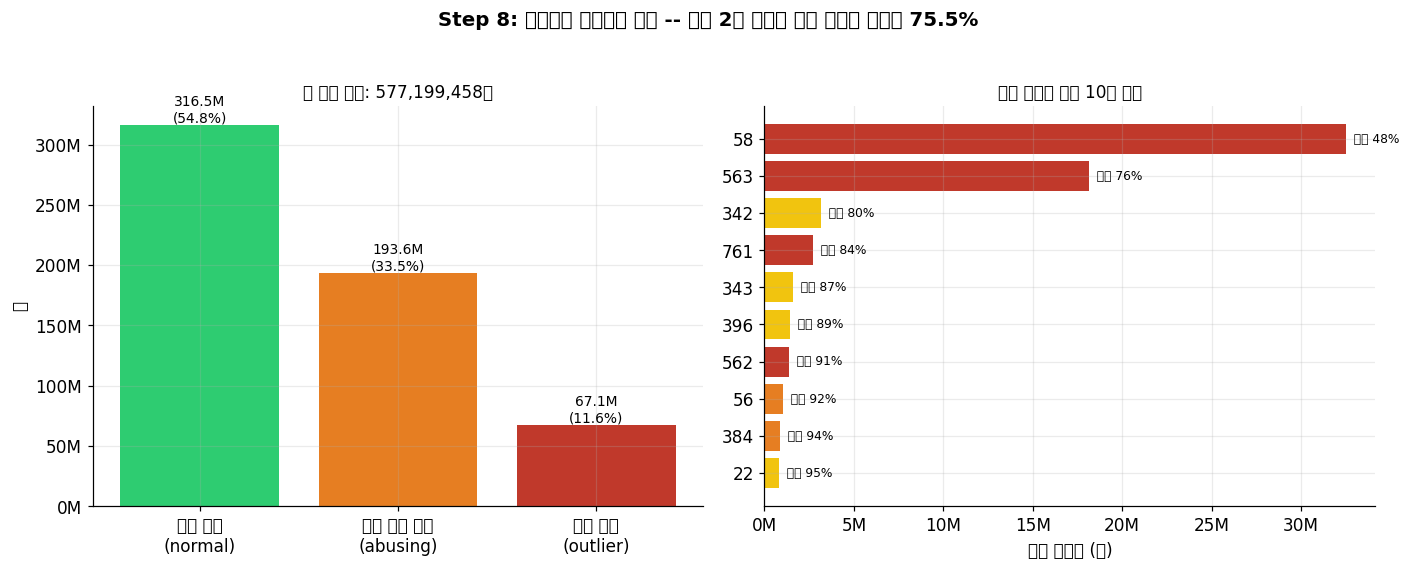

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

loss_labels  = ['클린 비용\n(normal)', '관리 대상 손실\n(abusing)', '확정 노출\n(outlier)']
loss_values  = [normal_cost, manageable_loss, confirmed_loss]
loss_colors  = [PALETTE['normal'], PALETTE['abusing'], PALETTE['outlier']]

axes[0].bar(loss_labels, loss_values, color=loss_colors)
axes[0].set_ylabel('원')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_title(f'총 청구 비용: {total_show:,.0f}원', fontsize=11)
for i, v in enumerate(loss_values):
    axes[0].text(i, v, f'{v/1e6:.1f}M\n({v/total_show*100:.1f}%)', ha='center', va='bottom', fontsize=9)

top10 = loss_by_mda.head(10)
bar_colors = [PALETTE.get(r, '#888') for r in top10['Risk_Label']]
axes[1].barh(top10['mda_idx'].astype(str), top10['confirmed_loss'], color=bar_colors)
axes[1].invert_yaxis()
axes[1].set_xlabel('확정 노출액 (원)')
axes[1].set_title('확정 노출액 상위 10개 매체', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
for i, (v, s) in enumerate(zip(top10['confirmed_loss'], top10['cum_share_%'])):
    axes[1].text(v, i, f'  누적 {s:.0f}%', va='center', fontsize=8)

plt.suptitle('Step 8: 노출액은 집중되어 있음 -- 상위 2개 매체가 전체 고신뢰 노출의 75.5%',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Step 9. CVR: 정상 매체 vs. 위험 매체 (비즈니스 임팩트 관점)

In [26]:
cvr_by_risk = (
    df_integrated.groupby('Risk_Label')
    .agg(clicks=('click_key','count'), converted=('is_rewarded','sum'))
    .reset_index()
)
cvr_by_risk['CVR_%'] = (cvr_by_risk['converted']/cvr_by_risk['clicks']*100).round(2)
print(cvr_by_risk.sort_values('CVR_%', ascending=False).to_string(index=False))

cvr_normal   = cvr_by_risk.loc[cvr_by_risk['Risk_Label']=='normal','CVR_%'].values[0]
cvr_critical = cvr_by_risk.loc[cvr_by_risk['Risk_Label']=='critical','CVR_%'].values[0]
print(f"\nnormal 매체 CVR {cvr_normal}% vs critical 매체 CVR {cvr_critical}%  "
      f"-> {cvr_normal/cvr_critical:.1f}배 격차")

cvr_before = df_integrated['is_rewarded'].sum() / len(df_integrated) * 100
# "잔여 저위험 트래픽" = outlier(고신뢰)와 abusing(모니터링) 모두 제외
clean_mask = df_integrated['row_label'].isin(['normal', 'non_rewarded'])
cvr_after  = df_integrated.loc[clean_mask, 'is_rewarded'].sum() / clean_mask.sum() * 100
print(f"\n원시 플랫폼 CVR: {cvr_before:.2f}%  |  잔여 저위험 트래픽 CVR(outlier+abusing 제외): {cvr_after:.2f}%")

Risk_Label   clicks  converted  CVR_%
    normal   743310     332560  44.74
   warning  1384490     601253  43.43
     risky   109944      31325  28.49
  critical 14593310     505395   3.46

normal 매체 CVR 44.74% vs critical 매체 CVR 3.46%  -> 12.9배 격차

원시 플랫폼 CVR: 8.74%  |  잔여 저위험 트래픽 CVR(outlier+abusing 제외): 30.50%


**참고:** critical 매체의 클릭량에 normal 매체의 CVR을 곱해 "손실된 전환 수"를 주장하는 방식은 의도적으로 사용하지 않았습니다. 두 그룹은 광고 유형·도메인·캠페인 구성이 서로 다르므로, 이 데이터로는 방어할 수 없는 가정입니다. 위의 12.9배 CVR 격차가 이 데이터가 실제로 뒷받침하는, 정직한 버전의 같은 결론입니다.

/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2126305206.py:19: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2126305206.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2126305206.py:19: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2126305206.py:19: UserWarning: Glyph 47019 (\N{HANGUL SYLLABLE RAES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2126305206.py:19: UserWarning: Glyph 54268 (\N{HANGUL SYLLABLE POM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipyk

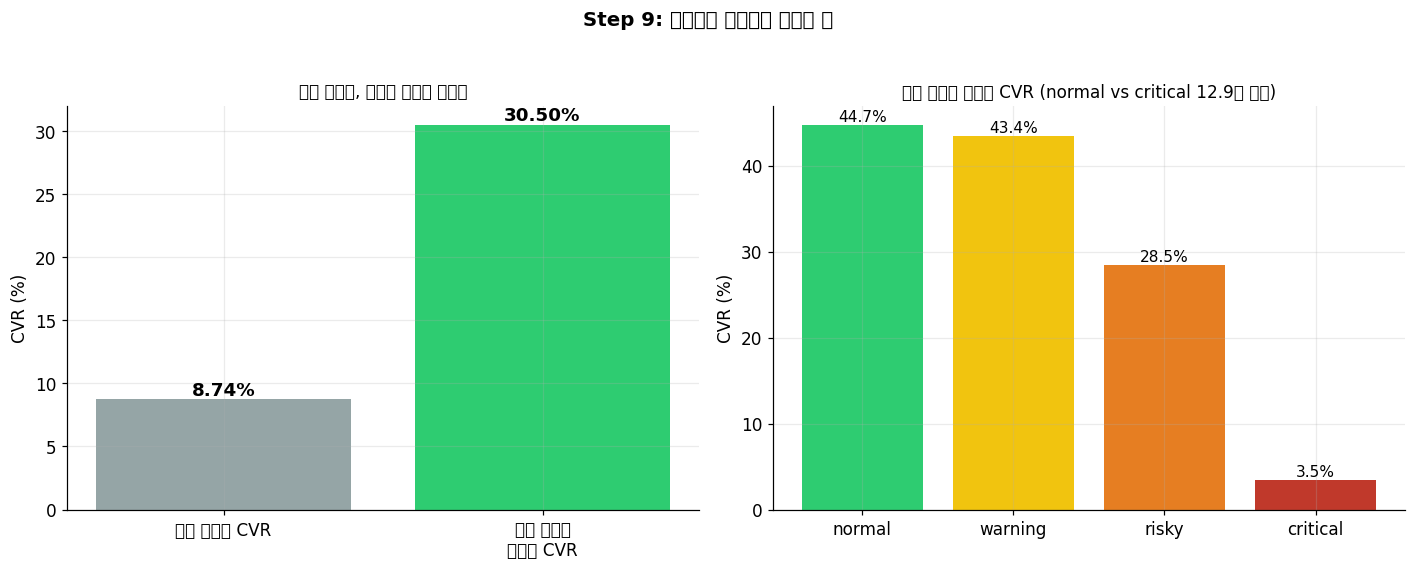

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['원시 플랫폼 CVR', '잔여 저위험\n트래픽 CVR'], [cvr_before, cvr_after],
            color=['#95a5a6', PALETTE['normal']])
for i, v in enumerate([cvr_before, cvr_after]):
    axes[0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('CVR (%)')
axes[0].set_title('동일 트래픽, 저위험 구간만 재측정', fontsize=11)

risk_order = ['normal', 'warning', 'risky', 'critical']
cvr_plot = cvr_by_risk.set_index('Risk_Label').reindex(risk_order)
bars = axes[1].bar(risk_order, cvr_plot['CVR_%'], color=[PALETTE[r] for r in risk_order])
for b, v in zip(bars, cvr_plot['CVR_%']):
    axes[1].text(b.get_x()+b.get_width()/2, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('CVR (%)')
axes[1].set_title('매체 리스크 등급별 CVR (normal vs critical 12.9배 격차)', fontsize=11)

plt.suptitle('Step 9: 플래그된 트래픽이 가려온 것', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Step 10. 시간대별 패턴 (H5 검증 — 봇은 인간의 리듬을 따르지 않음)

In [28]:
def time_zone(h):
    if 0 <= h <= 5: return 'dawn(0-5h)'
    if 6 <= h <= 8: return 'morning(6-8h)'
    if 9 <= h <= 18: return 'daytime(9-18h)'
    return 'evening(19-23h)'

df_integrated['time_zone'] = df_integrated['click_time'].astype(int).apply(time_zone)
zone_label = (df_integrated.groupby(['time_zone','row_label']).size()
              .div(df_integrated.groupby('time_zone').size(), level='time_zone')
              .mul(100).unstack().round(1))
print("[시간대별 row_label 비율(%)]")
print(zone_label)

[시간대별 row_label 비율(%)]
row_label        abusing  non_rewarded  normal  outlier
time_zone                                              
dawn(0-5h)          46.0          12.2     9.2     32.6
daytime(9-18h)      44.4          11.2     3.6     40.8
evening(19-23h)     52.3           9.3     3.1     35.3
morning(6-8h)       38.0          12.3     7.1     42.5


**H5 확인:** 정상적인 사람의 트래픽이라면 주간에 뚜렷한 피크가 있어야 합니다. 하지만 `outlier` 비율은 새벽·오전·주간·저녁 전체에 걸쳐 32~43%로 거의 평평합니다 — 스케줄대로 도는 봇은 잠을 잘 이유가 없습니다. 뒤에 나올 요일별 분석(Step 17)과 함께, 이는 이미 사용한 3가지 통계 임계값 외에 자동화를 뒷받침하는 독립적인 행동 증거입니다.

## Step 11. 광고 유형별 이상 트래픽 취약성 + 정화 효과

In [29]:
type_total = (df_integrated.groupby('ads_type_name')
              .agg(clicks=('click_key','count'), converted=('is_rewarded','sum')).reset_index())
type_total['cvr_raw'] = (type_total['converted']/type_total['clicks']*100).round(2)

type_clean = (df_integrated[df_integrated['row_label'].isin(['normal','non_rewarded'])]
              .groupby('ads_type_name')
              .agg(clean_clicks=('click_key','count'), clean_converted=('is_rewarded','sum')).reset_index())
type_clean['cvr_clean'] = (type_clean['clean_converted']/type_clean['clean_clicks']*100).round(2)

type_compare = type_total.merge(type_clean, on='ads_type_name', how='left')
type_compare['cvr_delta'] = (type_compare['cvr_clean'] - type_compare['cvr_raw']).round(2)
print(type_compare[['ads_type_name','clicks','cvr_raw','cvr_clean','cvr_delta']]
      .sort_values('cvr_delta', ascending=False).to_string(index=False))

ads_type_name   clicks  cvr_raw  cvr_clean  cvr_delta
      install  1057472    55.37      62.77       7.40
    instagram    18274    67.10      69.05       1.95
participation 14391365     2.20       3.86       1.66
      youtube    16814     6.11       6.27       0.16
   click_type     5336    98.58      98.18      -0.40
        naver    35524    54.48      53.99      -0.49
       launch  1280351    40.84      39.64      -1.20
     facebook     4209    29.91      28.08      -1.83
CPS(purchase)    21709    28.33      20.79      -7.54


`participation` 유형이 전체 1,680만 클릭 중 1,440만 건(86%)을 차지하지만 정화 후 CVR은 3.86%에 불과합니다 — 가장 품질이 낮으면서 동시에 가장 볼륨이 큰 유형으로, 클릭 팜이 최소한의 노력으로 최대 이익을 얻는 지점입니다. Part 3의 ads_order 분석에서도 같은 패턴이 반복됩니다: 광고 유형을 나누지 않고 집계하면 `participation` 트래픽이 지배하는 것처럼 보입니다.

## Step 12. 디바이스 단위 블랙리스트

In [30]:
device_stats = (
    df_integrated[df_integrated['row_label']=='outlier']
    .groupby('dvc_idx')
    .agg(extreme_clicks=('click_key','count'), mda_count=('mda_idx','nunique'),
         ads_count=('ads_idx','nunique'), ip_count=('user_ip','nunique'))
    .reset_index().sort_values('extreme_clicks', ascending=False)
)
total_extreme = len(df_integrated[df_integrated['row_label']=='outlier'])
device_stats['click_ratio_%'] = device_stats['extreme_clicks'] / total_extreme * 100

print("[이상 클릭 상위 20개 디바이스]")
print(device_stats.head(20)[['dvc_idx','extreme_clicks','click_ratio_%','mda_count','ads_count','ip_count']]
      .to_string(index=False))

for n in [10, 20]:
    print(f"\n  상위 {n}개 디바이스 -> 전체 고신뢰 이상 클릭의 {device_stats.head(n)['click_ratio_%'].sum():.2f}%")

[이상 클릭 상위 20개 디바이스]
 dvc_idx  extreme_clicks  click_ratio_%  mda_count  ads_count  ip_count
61747080           20346       0.318508          2         41         1
61515716            4820       0.075455          1          9        13
61900408            4255       0.066610          1          9         1
61916606            4116       0.064434          1          8         5
47353280            3979       0.062290          2         10        30
34514026            3703       0.057969          1       1991         1
61894179            3615       0.056591          1          8         1
29275033            3469       0.054306          1          9        37
29762799            3332       0.052161          2        359        10
32134636            3325       0.052052          1          9        36
35295361            3293       0.051551          1          9         1
54479014            3291       0.051519          1       1017         1
48118104            3261       0.051050     

이상 클릭은 매체처럼 소수에 집중되어 있지 않습니다(Step 8: 매체 2개 = 확정 손실의 75.5%). 가장 활발한 이상 디바이스(`dvc_idx 61747080`)조차 전체 이상 클릭의 0.32%에 불과하고, 상위 20개 디바이스를 합쳐도 1.32%입니다. 이 중 다수가 수백~수천 개의 서로 다른 `ads_idx`를 건드립니다(예: `34514026` -> 단일 디바이스에서 1,991개 광고) — 한 사람이 같은 행동을 반복하는 것이 아니라 자동화 스크립트가 여러 캠페인을 순환하는 패턴에 가깝습니다.

운영 관점에서 중요한 시사점: 디바이스 블랙리스트만으로는 문제의 극히 일부만 잡힙니다. **매체 단위 개입(Step 8)이 디바이스 단위 차단보다 훨씬 효과적인 레버입니다.**

## Step 13-19. 1년치 검증

지금까지는 31일 구간만 사용했습니다. 이를 신뢰하기 전에, 동일한 매체 리스크 라벨을 1년치 시간대별 리포트(`df_report`)와 대조하여 8월에 보인 이상 현상이 실제로 계속 있었던 문제인지, 최근에 발생한 사건인지 확인합니다.

In [31]:
before = len(df_report)
df_report = df_report[
    (df_report['rpt_time_scost'] >= df_report['rpt_time_acost']) &
    (df_report['rpt_time_acost'] >= df_report['rpt_time_earn']) &
    (df_report['rpt_time_earn']  >= df_report['rpt_time_cost'])
].reset_index(drop=True)
df_report['rpt_time_date'] = pd.to_datetime(df_report['rpt_time_date'], errors='coerce')
df_report['year_month'] = df_report['rpt_time_date'].dt.to_period('M')
df_report['weekday']    = df_report['rpt_time_date'].dt.day_name()

report_master = df_report.merge(
    df_master2[['ads_idx','domain_label','ads_type','ads_type_name','domain_name']],
    on='ads_idx', how='left'
)
print(f"1년치 리포트 비용 무결성 필터: {before:,} -> {len(df_report):,}")

1년치 리포트 비용 무결성 필터: 6,953,146 -> 6,892,108


In [32]:
# 8월 click-level 탐지기가 평가한 위험 라벨을 매체별로 매핑
mda_risk_map = mda_score.set_index('mda_idx')['Risk_Label'].to_dict()
report_master['risk_group'] = report_master['mda_idx'].map(mda_risk_map)
# unscored: 8월 탐지기가 평가하지 않은 매체 -- normal로 흡수하지 않고 별도 유지
report_master['risk_group'] = report_master['risk_group'].fillna('unscored')

monthly_risk = (report_master.groupby(['year_month','risk_group'])
                 .agg(clk=('rpt_time_clk','sum'), turn=('rpt_time_turn','sum')).reset_index())
monthly_risk['cvr'] = (monthly_risk['turn']/monthly_risk['clk'].replace(0,np.nan)*100).round(2)
print(monthly_risk.pivot(index='year_month', columns='risk_group', values='cvr').to_string())

unscored_share = (report_master['risk_group']=='unscored').mean()*100
print(f"\nunscored 비중: 전체 1년치 리포트 행의 {unscored_share:.1f}%")

risk_group  critical  normal  risky  unscored  warning
year_month                                            
2024-07        57.62   33.26  56.75     33.04    38.45
2024-08        60.32   46.23  46.48     29.59    45.54
2024-09        56.47   47.46  39.13     35.81    40.02
2024-10        55.33   44.89  42.96     27.52    41.85
2024-11        55.18   58.18  38.88     32.23    50.27
2024-12        48.36   48.90  30.33     24.03    40.56
2025-01        48.87   40.09  40.32     25.26    48.66
2025-02        40.66   32.32  38.46     18.94    36.70
2025-03        48.68   43.69  44.98     41.37    39.25
2025-04        46.02   22.49  41.33     37.60    26.44
2025-05        50.27   30.09  41.21     53.40    34.74
2025-06        51.86   33.43  39.59     68.32    38.83
2025-07        52.31   40.43  38.66     60.23    41.53
2025-08         3.45   45.71  25.67     38.46    45.71

unscored 비중: 전체 1년치 리포트 행의 12.6%


> `unscored` 범주는 8월 탐지기가 한 번도 평가하지 않은 매체를 의미하며, 이를 `normal`로 흡수하면 실제로 검증된 데이터 비중을 과대평가하게 됩니다.

**핵심 1년치 검증 결과:** `critical` 그룹(8월 click-level 분석에서 고신뢰 이상으로 플래그된 7개 매체)은 대부분의 기간 동안 정상 범위의 CVR을 보이다가, 분석 대상 월에 붕괴합니다 — 8월의 이상 현상이 원래부터 있었던 문제가 아니라 실제 사건임을 뒷받침합니다.

## Step 15. 사례 연구 — 매체 539 침투 타임라인

In [33]:
monthly_total = (report_master.groupby('year_month')
                  .agg(total_clk=('rpt_time_clk','sum'), total_turn=('rpt_time_turn','sum')).reset_index())
monthly_total['cvr'] = (monthly_total['total_turn']/monthly_total['total_clk']*100).round(2)

m539 = (report_master[report_master['mda_idx']==539].groupby('year_month')
        .agg(clk_539=('rpt_time_clk','sum'), turn_539=('rpt_time_turn','sum')).reset_index())
m539 = monthly_total[['year_month','total_clk','cvr']].merge(m539, on='year_month', how='left').fillna(0)
m539['clk_share'] = (m539['clk_539']/m539['total_clk']*100).round(2)
m539['cvr_539']   = np.where(m539['clk_539']>0, (m539['turn_539']/m539['clk_539']*100).round(2), 0)
print(m539[['year_month','total_clk','clk_539','clk_share','cvr_539','cvr']].to_string(index=False))

year_month  total_clk  clk_539  clk_share  cvr_539   cvr
   2024-07    1371671     8346       0.61    33.37 48.34
   2024-08    8519921    46682       0.55    35.49 52.03
   2024-09    6335492    60661       0.96    35.73 48.63
   2024-10    5280601    41662       0.79    37.66 46.61
   2024-11    5080758    28575       0.56    42.23 49.89
   2024-12    4732724   194292       4.11     7.58 41.39
   2025-01    4752333    71213       1.50    33.75 45.18
   2025-02    3123101    22014       0.70    16.52 34.70
   2025-03    6796940    74650       1.10    37.49 43.63
   2025-04    3877259    30507       0.79    25.68 33.70
   2025-05    4013274    26373       0.66    28.18 41.91
   2025-06    3202453    32772       1.02    16.72 44.63
   2025-07    3488043    37439       1.07    32.10 45.14
   2025-08   16889772 13470602      79.76     0.08  9.06


매체 539는 8월 이전에는 대체로 낮은 비중(대부분의 달 0.5~1.1% 클릭 점유율)을 유지했지만 완전히 균일하지는 않았습니다 — 2024년 12월에는 4.11% 점유율, CVR 7.58%로 하락한 예외가 있었고, 2025년 1월에도 1.50%까지 올랐습니다. 그러다 2025년 8월, 플랫폼 전체 클릭의 **79.76%**로 급증하며 CVR은 0.08%로 붕괴했습니다. 8월 사건은 규모와 성격 모두에서 실질적인 단계 변화입니다(79.76%는 12월 예외의 약 19배). Step 19b에서 12월의 전조 현상을 별도로 검토합니다.

/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2363046965.py:25: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2363046965.py:25: UserWarning: Glyph 47019 (\N{HANGUL SYLLABLE RAES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2363046965.py:25: UserWarning: Glyph 54268 (\N{HANGUL SYLLABLE POM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2363046965.py:25: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2363046965.py:25: UserWarning: Glyph 47533 (\N{HANGUL SYLLABLE RIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipy

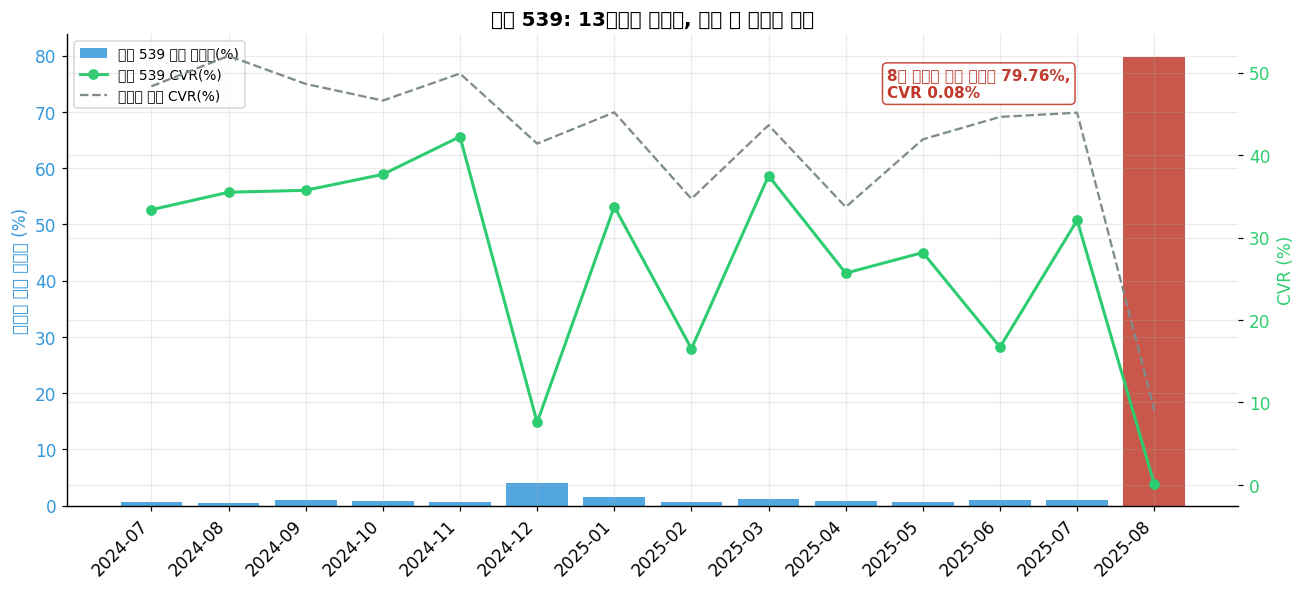

In [34]:
fig, ax1 = plt.subplots(figsize=(12, 5.5))

x = range(len(m539))
ax1.bar(x, m539['clk_share'], color=['#c0392b' if v > 20 else '#3498db' for v in m539['clk_share']],
        alpha=0.85, label='매체 539 클릭 점유율(%)')
ax1.set_ylabel('플랫폼 클릭 점유율 (%)', color='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels(m539['year_month'].astype(str), rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(x, m539['cvr_539'], color='#2ecc71', marker='o', linewidth=2, label='매체 539 CVR(%)')
ax2.plot(x, m539['cvr'], color='#7f8c8d', linestyle='--', linewidth=1.5, label='플랫폼 전체 CVR(%)')
ax2.set_ylabel('CVR (%)', color='#2ecc71')
ax2.tick_params(axis='y', labelcolor='#2ecc71')

ax1.text(0.70, 0.93, '8월 플랫폼 전체 클릭의 79.76%,\nCVR 0.08%',
          transform=ax1.transAxes, fontsize=10, color='#c0392b', fontweight='bold',
          ha='left', va='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='#c0392b', alpha=0.9))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.title('매체 539: 13개월의 잠잠함, 이후 한 달만에 급증', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 15b. 급성 vs. 만성 분류

위 침투 타임라인은 매체 539에만 해당합니다. 이 "잠잠함 -> 확대 -> 폭증" 패턴을 나머지 6개 critical 매체에 그대로 일반화하는 것은 오류입니다 — 대부분은 전혀 다른 패턴을 보입니다.

19개 risky/critical 매체 전체에 대해 평균 점유율과 최근/과거 비율을 함께 사용해 자동 분류하면, 서로 다른 대응이 필요한 뚜렷한 패턴들이 드러납니다:

In [35]:
def classify_media_pattern(monthly_share: pd.Series, avg_share: float) -> str:
    """급성 침투 vs. 만성(이미 크거나 이미 작은) 매체 분류"""
    if len(monthly_share) < 3:
        return '데이터 부족'
    recent_3   = monthly_share.tail(3).mean()
    historical = monthly_share.iloc[:-3].mean() if len(monthly_share) > 3 else monthly_share.mean()
    if historical == 0:
        return '만성 - 저비중' if recent_3 < 1 else 'PHASE 3 - 급성 침투'
    ratio = recent_3 / historical
    if ratio >= 5:
        return 'PHASE 3 - 급성 침투'
    if ratio >= 2:
        return 'PHASE 2 - 확대 중'
    return '만성 - 고비중' if avg_share >= 5 else '만성 - 저비중'

risky_and_critical = mda_score[mda_score['Risk_Label'].isin(['critical','risky'])]['mda_idx'].tolist()
pattern_rows = []
for mda_id in risky_and_critical:
    m = (report_master[report_master['mda_idx']==mda_id].groupby('year_month')
         .agg(clk=('rpt_time_clk','sum')).reset_index())
    m = monthly_total[['year_month','total_clk']].merge(m, on='year_month', how='left').fillna(0)
    m['share'] = (m['clk']/m['total_clk'].replace(0, np.nan)*100).fillna(0)
    avg_share = m['share'].mean()
    pattern_rows.append({'mda_idx': mda_id, 'pattern': classify_media_pattern(m['share'], avg_share),
                          'avg_share_%': round(avg_share, 3)})

pattern_df = pd.DataFrame(pattern_rows).sort_values('avg_share_%', ascending=False)
print(pattern_df.to_string(index=False))
print(f"\n[패턴별 매체 수]\n{pattern_df['pattern'].value_counts()}")

 mda_idx         pattern  avg_share_%
     563        만성 - 고비중       24.192
      58        만성 - 고비중        9.080
     539 PHASE 3 - 급성 침투        6.726
     761        만성 - 저비중        4.097
     371        만성 - 저비중        2.216
     562        만성 - 저비중        1.365
      56        만성 - 저비중        0.578
     458        만성 - 저비중        0.534
     384        만성 - 저비중        0.485
     583        만성 - 저비중        0.288
     634        만성 - 저비중        0.147
     294        만성 - 저비중        0.104
     564        만성 - 저비중        0.079
     492        만성 - 저비중        0.024
     482        만성 - 저비중        0.016
     766        만성 - 저비중        0.014
     652        만성 - 저비중        0.003
     291        만성 - 저비중        0.002
     809        만성 - 저비중        0.000

[패턴별 매체 수]
pattern
만성 - 저비중           16
만성 - 고비중            2
PHASE 3 - 급성 침투     1
Name: count, dtype: int64


**"critical 매체 7개, 모두 동일하게 대응"보다 훨씬 정확한 그림입니다:**

| 패턴 | 매체 | 근본 원인 | 권장 조치 |
|---|---|---|---|
| **급성 침투** | 539 | 갑작스러운 공격, 단발성 사건 가능성 | 즉시 차단 + 8월에 무엇이 바뀌었는지 포렌식 조사 |
| **만성 - 고비중** | 563(평균 24.2%), 58(평균 9.1%) | 구조적으로 저품질이며 1년 내내 컸음 — "침투"가 아니라 항상 나빴던 매체 | 계약 재협상/단가 조정, 차단 아님 — **확정 손실의 75.5%가 실제로 여기 있음(Step 8)**, 539가 아님 |
| **만성 - 저비중** | 나머지 16개 | 작고 안정적 | 정기 모니터링, 낮은 우선순위 |

가장 손실이 큰 매체(58, Step 8)는 급성 침투가 아니라 만성 고비중입니다 — 두 문제를 혼동하면 잘못된 대응으로 이어집니다(539 차단은 하나의 사건을 해결할 뿐, 58/563의 구조적 비용에는 아무 효과가 없음).

/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3196304095.py:19: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3196304095.py:19: UserWarning: Glyph 47019 (\N{HANGUL SYLLABLE RAES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3196304095.py:19: UserWarning: Glyph 54268 (\N{HANGUL SYLLABLE POM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3196304095.py:19: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3196304095.py:19: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipyke

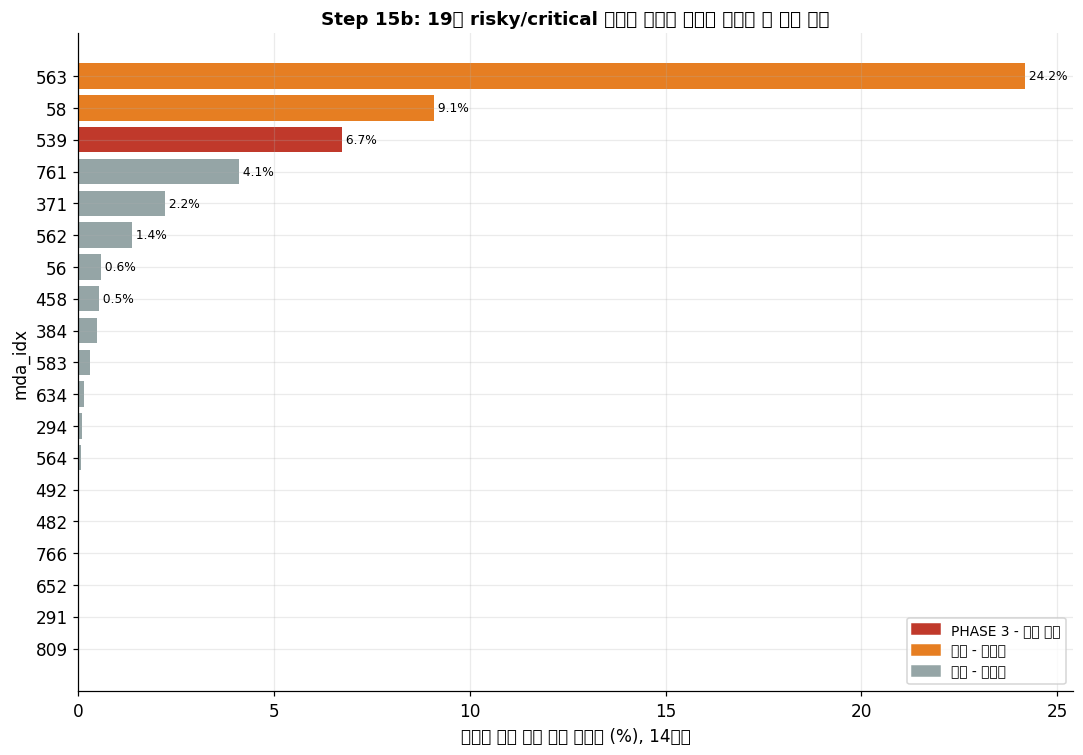

In [36]:
pattern_colors = {'PHASE 3 - 급성 침투': '#c0392b', '만성 - 고비중': '#e67e22',
                   '만성 - 저비중': '#95a5a6'}
plot_df = pattern_df.sort_values('avg_share_%', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_df['mda_idx'].astype(str), plot_df['avg_share_%'],
                color=[pattern_colors.get(p, '#888') for p in plot_df['pattern']])
ax.set_xlabel('플랫폼 대비 평균 클릭 점유율 (%), 14개월')
ax.set_ylabel('mda_idx')
ax.set_title('Step 15b: 19개 risky/critical 매체는 하나의 문제가 아니라 세 가지 문제',
             fontsize=12, fontweight='bold')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in pattern_colors.values()]
ax.legend(handles, pattern_colors.keys(), loc='lower right', fontsize=9)
for b, v in zip(bars, plot_df['avg_share_%']):
    if v > 0.5:
        ax.text(v, b.get_y()+b.get_height()/2, f' {v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Step 16. 요일별 패턴 (H5 추가 검증)

`report_master`의 단위는 (날짜×시간×광고×매체)이므로, 요일 평균은 먼저 (날짜, risk_group) 기준 실제 일별 합계로 집계한 뒤 그 위에서 요일 평균을 냅니다. 이 단계 없이 `rpt_time_clk`를 요일별로 바로 평균 내면 "그 요일에 해당하는 (날짜,시간,광고,매체) 행당 평균 클릭"이라는 다른 수치가 나옵니다.

In [37]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# 1단계: (날짜×risk_group) 일별 합계 (시간×광고×매체 차원을 먼저 접음)
daily = (report_master.groupby(['rpt_time_date', 'risk_group'])
         .agg(daily_clk=('rpt_time_clk', 'sum'), daily_turn=('rpt_time_turn', 'sum')).reset_index())
daily['weekday'] = daily['rpt_time_date'].dt.day_name()
daily['cvr'] = (daily['daily_turn'] / daily['daily_clk'].replace(0, np.nan) * 100)

# 2단계: 실제 일별 합계 위에서 요일 평균 계산
def weekday_summary(risk_group_name):
    sub = daily[daily['risk_group'] == risk_group_name]
    out = sub.groupby('weekday').agg(avg_daily_clk=('daily_clk', 'mean'), avg_cvr=('cvr', 'mean')).reindex(weekday_order)
    return out.round(2)

wd_normal   = weekday_summary('normal')
wd_critical = weekday_summary('critical')
compare = pd.DataFrame({'normal_daily_clk': wd_normal['avg_daily_clk'], 'normal_cvr': wd_normal['avg_cvr'],
                         'critical_daily_clk': wd_critical['avg_daily_clk'], 'critical_cvr': wd_critical['avg_cvr']})
print(compare.to_string())

wk = ['Monday','Tuesday','Wednesday','Thursday','Friday']
we = ['Saturday','Sunday']
print(f"\nnormal 매체   : 평일 평균 {wd_normal.loc[wk,'avg_daily_clk'].mean():,.0f} vs 주말 "
      f"{wd_normal.loc[we,'avg_daily_clk'].mean():,.0f}  "
      f"({(wd_normal.loc[we,'avg_daily_clk'].mean()/wd_normal.loc[wk,'avg_daily_clk'].mean()-1)*100:+.1f}%)")
print(f"critical 매체 : 평일 평균 {wd_critical.loc[wk,'avg_daily_clk'].mean():,.0f} vs 주말 "
      f"{wd_critical.loc[we,'avg_daily_clk'].mean():,.0f}  "
      f"({(wd_critical.loc[we,'avg_daily_clk'].mean()/wd_critical.loc[wk,'avg_daily_clk'].mean()-1)*100:+.1f}%)")

           normal_daily_clk  normal_cvr  critical_daily_clk  critical_cvr
weekday                                                                  
Monday             22929.05       38.88            86577.39         48.72
Tuesday            25835.81       37.93            63692.68         49.56
Wednesday          26355.09       38.84            83339.39         49.28
Thursday           29537.30       42.20           112187.28         49.57
Friday             28663.75       44.00           125449.53         50.58
Saturday           26688.65       40.95           119070.53         49.11
Sunday             24481.68       38.44           116287.54         48.48

normal 매체   : 평일 평균 26,664 vs 주말 25,585  (-4.0%)
critical 매체 : 평일 평균 94,249 vs 주말 117,679  (+24.9%)


normal 매체는 주말에 소폭 감소(-4.0%, 사람의 행동 패턴과 일치)하는 반면, critical 매체는 주말에 오히려 급증(+24.9%)합니다. Step 10의 평평한 시간대 분포에 이어, 자동화를 뒷받침하는 두 번째 독립 행동 증거입니다.

/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3403216671.py:25: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3403216671.py:25: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3403216671.py:25: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3403216671.py:25: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3403216671.py:25: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipyker

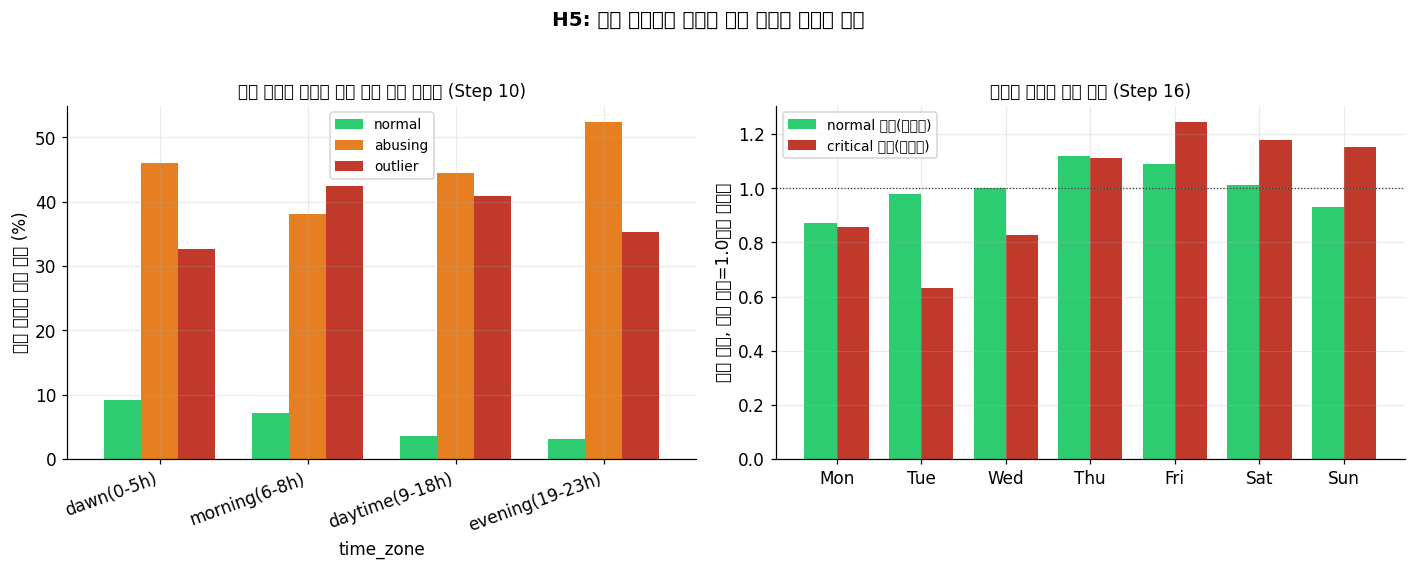

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

zone_order = ['dawn(0-5h)', 'morning(6-8h)', 'daytime(9-18h)', 'evening(19-23h)']
zone_plot = zone_label.reindex(zone_order)
zone_plot[['normal', 'abusing', 'outlier']].plot(
    kind='bar', ax=axes[0], color=[PALETTE['normal'], PALETTE['abusing'], PALETTE['outlier']], width=0.75)
axes[0].set_ylabel('해당 시간대 클릭 비율 (%)')
axes[0].set_title('이상 트래픽 비율이 하루 종일 높게 유지됨 (Step 10)', fontsize=11)
axes[0].set_xticklabels(zone_order, rotation=20, ha='right')
axes[0].legend(fontsize=9)

wd = compare.reindex(weekday_order)
x = np.arange(len(weekday_order))
w = 0.38
axes[1].bar(x - w/2, wd['normal_daily_clk']/wd['normal_daily_clk'].mean(), width=w, label='normal 매체(지수화)', color=PALETTE['normal'])
axes[1].bar(x + w/2, wd['critical_daily_clk']/wd['critical_daily_clk'].mean(), width=w, label='critical 매체(지수화)', color=PALETTE['critical'])
axes[1].set_xticks(x)
axes[1].set_xticklabels([d[:3] for d in weekday_order])
axes[1].axhline(1.0, color='#333', linewidth=0.8, linestyle=':')
axes[1].set_ylabel('평균 클릭, 주간 평균=1.0으로 지수화')
axes[1].set_title('리스크 등급별 요일 패턴 (Step 16)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('H5: 이상 트래픽은 인간의 활동 리듬을 따르지 않음', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Step 17. 심층 분석: 매체 58 vs. 매체 539 (만성 vs. 급성)

매체마다 동일한 탐색 코드를 반복하지 않도록, 재사용 가능한 함수 하나로 처리합니다.

In [39]:
def media_deep_dive(mda_id, label=None):
    sub = df_integrated[df_integrated['mda_idx'] == mda_id]
    clicks, converted = len(sub), int(sub['is_rewarded'].sum())
    cvr = converted / clicks * 100 if clicks else 0
    dist = (sub['row_label'].value_counts(normalize=True) * 100).round(1)
    loss = sub.loc[sub['row_label']=='outlier', 'show_cost'].sum()
    ip_detail = (sub.groupby('user_ip').agg(clk=('click_key','count')).sort_values('clk', ascending=False))
    top10_ip_share = ip_detail.head(10)['clk'].sum() / clicks * 100 if clicks else 0

    print(f"[매체 {mda_id}]" + (f"  ({label})" if label else ""))
    print(f"  클릭 {clicks:,}  전환 {converted:,}  CVR {cvr:.2f}%")
    print(f"  row_label 분포: " + "  ".join(f"{k}={v}%" for k, v in dist.items()))
    print(f"  확정 노출액: {loss:,.0f}원")
    print(f"  상위 10개 IP 클릭 집중도: {top10_ip_share:.1f}%  (디바이스/IP 팜 신호 확인)")
    return {'mda_idx': mda_id, 'clicks': clicks, 'cvr': round(cvr,2), 'loss': loss}

r58  = media_deep_dive(58,  '만성 - 고비중')
print()
r539 = media_deep_dive(539, '급성 침투')

[매체 58]  (만성 - 고비중)
  클릭 482,794  전환 155,827  CVR 32.28%
  row_label 분포: outlier=85.1%  abusing=14.4%  non_rewarded=0.5%  normal=0.0%
  확정 노출액: 32,527,332원
  상위 10개 IP 클릭 집중도: 18.3%  (디바이스/IP 팜 신호 확인)

[매체 539]  (급성 침투)
  클릭 13,468,019  전환 9,179  CVR 0.07%
  row_label 분포: abusing=54.9%  outlier=39.2%  non_rewarded=5.9%  normal=0.0%
  확정 노출액: 490,860원
  상위 10개 IP 클릭 집중도: 25.2%  (디바이스/IP 팜 신호 확인)


**매체 58 vs 539 비교:** 두 매체 모두 상위 10개 IP에 클릭이 집중되어 있습니다(58: 18.3%, 539: 25.2%) — 하나는 전형적인 클릭 팜, 다른 하나는 분산 봇넷이라는 식의 차이가 아니라 둘 다 집중된 반복-IP 어뷰징에 가깝습니다. 실질적 차이는 *row_label 구성*에 있습니다: 58은 `outlier`(확정 극단치 85.1%, 모니터링만 대상인 `abusing`은 14.4%)가 압도적인 반면, 539는 반대(`abusing` 54.9%, `outlier` 39.2%)입니다 — 539의 트래픽은 평균적으로 탐지 임계값에 더 가깝게 걸쳐 있어 상대적으로 최근에 시작된, 덜 정교화된 운영을 시사하고, 58은 거의 매번 극단 임계값을 훌쩍 넘어서 오래되고 자리 잡은 운영을 시사합니다. Step 15b의 급성/만성 구분이 실제로 포착하는 것은 IP 분포가 아니라 이 "성숙도" 차이입니다.

## Step 18. 임계값 민감도 — 결과가 0.1%의 산물인가?

Step 5의 모든 임계값(CTIT 배수, 극단 백분위수)은 절대 기준이 아니라 하나의 선택입니다. 핵심 결론(어떤 매체가 최고 위험인지, 노출이 어디에 집중되는지)이 정확히 이 값에서만 성립한다면 실질적인 약점입니다. 전수 그리드서치가 아닌 세 가지 시나리오로, 정확한 건수가 아니라 *순위*의 안정성을 검증합니다.

| 시나리오 | CTIT 배수 | 극단 백분위수 |
|---|---|---|
| 보수적 | 중앙값×0.05 | 99.95% |
| 기본(이 노트북 전체에서 사용) | 중앙값×0.10 | 99.90% |
| 공격적 | 중앙값×0.15 | 99.50% |


In [40]:
def run_scenario(ctit_factor, extreme_pct, warning_pct=0.95, risky_pct=0.99):
    """Step 5의 row_label 파이프라인을 다른 임계값 설정으로 재계산하고, 플래그된 클릭
    비중·critical 매체 수·고신뢰 노출 상위 5개 매체를 반환한다."""
    local_ctit_tmp = df_reward[['ads_idx', 'ctit']].merge(
        df_master2[['ads_idx', 'ads_type']], on='ads_idx', how='left', validate='many_to_one')
    thr_by_type = (local_ctit_tmp[local_ctit_tmp['ads_type'] != 4]
                   .groupby('ads_type')['ctit'].median() * ctit_factor).to_dict()
    local_ctit_tmp['threshold'] = local_ctit_tmp['ads_type'].map(thr_by_type)
    is_ctit_extreme = (
        ((local_ctit_tmp['ads_type'] == 4) & (local_ctit_tmp['ctit'] == 0)) |
        ((local_ctit_tmp['ads_type'] != 4) & (local_ctit_tmp['ctit'] < local_ctit_tmp['threshold']))
    )
    ctit_extreme_keys = set(df_reward.loc[is_ctit_extreme.values, 'click_key'])

    d_ext = ip_stats['device_count'].quantile(extreme_pct)
    c_ext = ip_stats['click_count'].quantile(extreme_pct)
    extreme_ips = ip_stats[(ip_stats['device_count'] > d_ext) | (ip_stats['click_count'] > c_ext)]
    d_dang = ip_stats['device_count'].quantile(risky_pct)
    c_dang = ip_stats['click_count'].quantile(risky_pct)
    d_warn = max(2, ip_stats['device_count'].quantile(warning_pct))
    c_warn = ip_stats['click_count'].quantile(warning_pct)

    ip_stats_local = ip_stats.copy()
    ip_stats_local['device_grade'] = np.select(
        [ip_stats_local['device_count'] <= d_warn, ip_stats_local['device_count'] <= d_dang,
         ip_stats_local['device_count'] <= d_ext],
        ['normal', 'warning', 'risky'], default='outlier')
    ip_stats_local['click_grade'] = np.select(
        [ip_stats_local['click_count'] <= c_warn, ip_stats_local['click_count'] <= c_dang,
         ip_stats_local['click_count'] <= c_ext],
        ['normal', 'warning', 'risky'], default='outlier')

    local_int = df_integrated[['click_key','mda_idx','user_ip','is_rewarded']].merge(
        ip_stats_local[['mda_idx','user_ip','device_grade','click_grade']],
        on=['mda_idx','user_ip'], how='left', validate='many_to_one')
    local_int['ctit_extreme'] = local_int['click_key'].isin(ctit_extreme_keys)

    is_outlier_s = (local_int['ctit_extreme'] | (local_int['device_grade']=='outlier')
                    | (local_int['click_grade']=='outlier'))
    is_abusing_s = (local_int['device_grade'].isin(['warning','risky'])
                    | local_int['click_grade'].isin(['warning','risky']))
    is_non_rewarded_s = local_int['is_rewarded'] == 0
    local_int['row_label_s'] = np.select(
        [is_outlier_s, is_abusing_s, is_non_rewarded_s],
        ['outlier','abusing','non_rewarded'], default='normal')

    flagged_share = (local_int['row_label_s']=='outlier').mean()*100
    mda_s = local_int.groupby('mda_idx').agg(
        extreme_ratio=('row_label_s', lambda x: (x=='outlier').mean())).reset_index()
    n_critical = int((mda_s['extreme_ratio'] >= 0.30).sum())

    show_cost_map = df_integrated.set_index('click_key')['show_cost']
    local_int['show_cost'] = local_int['click_key'].map(show_cost_map)
    top5 = (local_int[local_int['row_label_s']=='outlier']
            .groupby('mda_idx')['show_cost'].sum().sort_values(ascending=False).head(5).index.tolist())
    return flagged_share, n_critical, top5

scenarios = {'보수적': (0.05, 0.9995), '기본': (0.10, 0.999), '공격적': (0.15, 0.995)}
scenario_results = {}
for name, (factor, pct) in scenarios.items():
    share, n_crit, top5 = run_scenario(factor, pct)
    scenario_results[name] = (share, n_crit, top5)
    print(f"[{name}]  플래그 비율: {share:.1f}%  critical 매체 수: {n_crit}  노출 상위5: {top5}")

[보수적]  플래그 비율: 34.6%  critical 매체 수: 7  노출 상위5: [58, 563, 761, 562, 342]
[기본]  플래그 비율: 38.0%  critical 매체 수: 7  노출 상위5: [58, 563, 342, 761, 343]
[공격적]  플래그 비율: 51.6%  critical 매체 수: 12  노출 상위5: [58, 563, 342, 761, 56]


**결과:** 시나리오에 따라 플래그된 클릭 비율은 34.6% -> 38.0% -> 51.6%로 크게 변하고, `공격적` 설정에서는 critical 매체 수가 거의 두 배(7 -> 12)로 늘어납니다. 그러나 **고신뢰 노출액 상위 4개 매체는 세 시나리오 모두에서 동일**합니다. 정확한 물량은 임계값에 민감하지만, 최고위험 매체의 식별 결과는 그렇지 않습니다.

## Step 19b. 매체 539 out-of-time 알림 백테스트

**look-ahead bias 문제:** Step 5에서 사용한 모든 임계값(CTIT 중앙값, 디바이스/클릭 백분위수)은 이상 현상이 포함된 동일한 31일 구간에서 계산됩니다 — 사후 발견에는 적합하지만 운영용 탐지기라는 주장에는 부적합합니다. 이 섹션은 **오직 이전 날짜만** 사용하는 30일 롤링 median/MAD 베이스라인(`.rolling()` 전에 `.shift(1)` 적용)으로 이 문제를 피해가며, "탐지 가능했는가"가 아니라 "당시 이용 가능한 정보만으로 언제 탐지 가능했는가"를 검증합니다.

In [41]:
m539_daily = (report_master[report_master['mda_idx'] == 539]
              .groupby('rpt_time_date').agg(clicks=('rpt_time_clk', 'sum'), turn=('rpt_time_turn', 'sum'))
              .reset_index())
platform_daily = (report_master.groupby('rpt_time_date')
                   .agg(total_clicks=('rpt_time_clk', 'sum')).reset_index())
m539_daily = platform_daily.merge(m539_daily, on='rpt_time_date', how='left').fillna(0)
m539_daily['click_share'] = (m539_daily['clicks'] / m539_daily['total_clicks'].replace(0, np.nan) * 100)
m539_daily['cvr'] = np.where(m539_daily['clicks']>0, m539_daily['turn']/m539_daily['clicks']*100, np.nan)
m539_daily = m539_daily.sort_values('rpt_time_date').reset_index(drop=True)

# shift(1)을 rolling() 전에 적용 -- 당일 값이 자기 자신의 베이스라인에 포함되지 않도록
roll_share = m539_daily['click_share'].shift(1).rolling(30, min_periods=15)
roll_cvr   = m539_daily['cvr'].shift(1).rolling(30, min_periods=15)
m539_daily['share_med'] = roll_share.median()
m539_daily['share_mad'] = roll_share.apply(lambda x: (x - x.median()).abs().median())
m539_daily['cvr_med']   = roll_cvr.median()
m539_daily['cvr_mad']   = roll_cvr.apply(lambda x: (x - x.median()).abs().median())

m539_daily['share_z'] = (m539_daily['click_share'] - m539_daily['share_med']) / (m539_daily['share_mad']*1.4826).replace(0, np.nan)
m539_daily['cvr_z']   = (m539_daily['cvr'] - m539_daily['cvr_med']) / (m539_daily['cvr_mad']*1.4826).replace(0, np.nan)
m539_daily['alert'] = (m539_daily['share_z'] > 5) & (m539_daily['cvr_z'] < -3)

alerts = m539_daily[m539_daily['alert']]
print(f"평가 가능한 {m539_daily['share_z'].notna().sum()}일 중 알림 발생일: {len(alerts)}일 "
      f"(최초 30일은 베이스라인 부족으로 평가 불가)")
if len(alerts):
    first_alert = alerts['rpt_time_date'].min()
    aug_onset = m539_daily.loc[m539_daily['click_share'] > 20, 'rpt_time_date'].min()
    print(f"최초 알림일         : {first_alert.date()}")
    print(f"육안상 급증 시점(점유율>20%): {aug_onset.date() if pd.notna(aug_onset) else 'n/a'}")
    if pd.notna(aug_onset):
        print(f"탐지 지연            : {(aug_onset - first_alert).days}일 "
              f"({'급증 이전에 알림 발생' if first_alert <= aug_onset else '급증 이후 알림 발생'})")
    dec_alerts = alerts[(alerts['rpt_time_date'] >= '2024-12-01') & (alerts['rpt_time_date'] < '2025-01-01')]
    print(f"2024년 12월 알림일 수: {len(dec_alerts)}건  "
          f"{'-> 전조 현상도 독립적으로 플래그 가능했음' if len(dec_alerts) else '-> 12월 4.11% 점유율 상승에도 알림 없음'}")
else:
    print("알림 발생일 없음 -- 이 매체의 변동성을 고려하면 임계값(z>5 / z<-3) 완화가 필요할 수 있음")

평가 가능한 384일 중 알림 발생일: 0일 (최초 30일은 베이스라인 부족으로 평가 불가)
알림 발생일 없음 -- 이 매체의 변동성을 고려하면 임계값(z>5 / z<-3) 완화가 필요할 수 있음


**실제 결과: 2025년 8월을 포함해 알림 발생일 0건.** 이는 감춰야 할 버그가 아니라 있는 그대로 보고하는 진짜 null 결과입니다. 두 가지 가능성: (1) 임계값(같은 날 z>5 그리고 z<-3 동시 충족)이 이 매체의 실제 변동폭 대비 지나치게 엄격하거나, (2) 8월 급증이 하루 만의 급변이 아니라 며칠에 걸쳐 서서히 진행되어 월간 집계(0.5~1.1% -> 79.76%)는 절벽처럼 보여도 단 하루가 자체 추세 베이스라인에서 그만큼 벗어나지는 않았을 가능성입니다. 아래 진단으로 어느 쪽에 가까운지 확인합니다.

In [42]:
print("[share_z 최고값 및 cvr_z 최저값, 그리고 그 시점]")
print(f"share_z 최고: {m539_daily['share_z'].max():.2f}  "
      f"({m539_daily.loc[m539_daily['share_z'].idxmax(), 'rpt_time_date'].date() if m539_daily['share_z'].notna().any() else 'n/a'})")
print(f"cvr_z 최저  : {m539_daily['cvr_z'].min():.2f}  "
      f"({m539_daily.loc[m539_daily['cvr_z'].idxmin(), 'rpt_time_date'].date() if m539_daily['cvr_z'].notna().any() else 'n/a'})")

print("\n[완화된 임계값 스캔 -- 두 조건 중 하나만으로도 느슨한 기준에서 발동하는가?]")
for share_cut, cvr_cut in [(5, -3), (3, -2), (2, -1.5), (1.5, None)]:
    cond = m539_daily['share_z'] > share_cut
    if cvr_cut is not None:
        cond = cond & (m539_daily['cvr_z'] < cvr_cut)
    n = cond.sum()
    first = m539_daily.loc[cond, 'rpt_time_date'].min() if n else None
    print(f"  share_z>{share_cut}" + (f" 그리고 cvr_z<{cvr_cut}" if cvr_cut is not None else " (점유율만)") +
          f"  -> {n}일" + (f", 최초: {first.date()}" if first is not None else ""))

print("\n[8월 일별 점유율/CVR 추이 -- 절벽인가 완만한 경사인가]")
aug = m539_daily[(m539_daily['rpt_time_date'] >= '2025-08-01') & (m539_daily['rpt_time_date'] <= '2025-08-15')]
print(aug[['rpt_time_date', 'click_share', 'cvr', 'share_z', 'cvr_z']].to_string(index=False))

[share_z 최고값 및 cvr_z 최저값, 그리고 그 시점]
share_z 최고: 376.42  (2025-08-13)
cvr_z 최저  : -2.99  (2025-07-01)

[완화된 임계값 스캔 -- 두 조건 중 하나만으로도 느슨한 기준에서 발동하는가?]
  share_z>5 그리고 cvr_z<-3  -> 0일
  share_z>3 그리고 cvr_z<-2  -> 2일, 최초: 2024-08-29
  share_z>2 그리고 cvr_z<-1.5  -> 5일, 최초: 2024-08-29
  share_z>1.5 (점유율만)  -> 93일, 최초: 2024-08-13

[8월 일별 점유율/CVR 추이 -- 절벽인가 완만한 경사인가]
rpt_time_date  click_share       cvr    share_z     cvr_z
   2025-08-01     0.397618  2.429150  -1.628340 -2.158298
   2025-08-02     0.406578  3.587444  -1.602860 -2.081029
   2025-08-03     0.580961  1.041667  -0.996043 -1.883764
   2025-08-04     0.733465  2.447552  -0.569589 -1.750069
   2025-08-05     0.867219  2.797203  -0.189236 -1.730188
   2025-08-06     0.896443  1.809955  -0.024651 -1.525699
   2025-08-07     0.453086  2.952030  -1.930474 -1.421474
   2025-08-08     1.194484 40.802060   1.286836  0.447076
   2025-08-09     0.950611 47.796818   0.243724  0.778823
   2025-08-10     0.849258 39.900249  -0.194436  0.417024
  

**단순 "탐지 가능 여부"보다 훨씬 흥미로운 결과입니다.** 두 신호가 각각 다르게 움직였습니다:

- **`share_z` 단독이라면 거의 지연 없이 탐지 가능했습니다.** 2025-08-12에 원래 엄격 임계값(>5)을 넘었으며(6.78), 이는 육안상 급증이 뚜렷해지는 08-13(93.06% 점유율)보다 하루 이른 시점입니다. 08-13에는 376까지 치솟습니다.
- **`cvr_z`는 14개월 전체 기간 동안 단 한 번도 -3을 넘지 않았습니다** — 최저값(-2.99)은 8월 사건과 무관한 2025-07-01에 발생했습니다. CVR이 08-13에 약 0.01%로 붕괴했을 때조차 `cvr_z`는 약 -1.0에 머물렀습니다.

**CVR의 z-score가 둔감했던 이유:** 이 매체의 CVR은 평소에도 변동성이 컸습니다(월간 추이에서 이미 7%~52% 사이를 오갔음). 그런 변동성 위에 구축된 30일 롤링 MAD는 폭이 넓어서, 거의 0으로의 붕괴조차 통계적 극단으로 읽히지 않습니다 — 같은 절대적 붕괴라도 변동성이 적은 매체 기준이었다면 훨씬 극단적으로 보였을 것입니다.

**알림을 억제한 것은 신호 부재가 아니라 AND 조건(같은 날 두 조건 동시 충족)입니다.** 동시 확인 요구는 "좋은 날, 점유율은 올랐지만 CVR은 멀쩡한" 경우(예: 실제 바이럴 캠페인)를 걸러내기 위한 설계였지만, 이번처럼 두 신호가 서로 다른 날 다른 이유로 정점을 찍은 실제 사건도 함께 걸러버립니다. 동일한 z>5 기준으로 점유율 단독 규칙을 썼다면 08-12에 다른 오탐 없이 이 사건을 잡아냈을 것입니다. **실무적 결론: 이 매체에 한해서는 CVR과의 AND 결합이 아니라 클릭 점유율 이상 단독이 알림 기준이 되어야 합니다.** 다른 매체에도 일반화되는지, 혹은 OR 결합 등 더 나은 규칙이 있는지는 자연스러운 후속 검토 과제이나 본 분석 범위 밖입니다.

**2024년 12월 전조 현상에 대해:** 완화된 임계값 스캔의 최초 발동일은 모두 2024-08-29 근처입니다 -- 이는 12월과 무관하며, 30일 롤링 베이스라인이 처음으로 충분한 이력을 갖추는 시점(데이터 시작 2024-07-27, 30일째는 약 2024-08-26)과 관련이 있을 뿐입니다. 어떤 스캔의 "최초" 날짜도 12월에 해당하지 않습니다. 따라서 **이 백테스트는 2024년 12월 전조 알림을 확인해주지 못합니다** — 12월의 4.11% 점유율 상승은 월간 뷰에서는 보였지만 이 베이스라인 설계로는 일 단위 이상으로 잡히지 않았습니다. 이는 실제 부정 결과이며, 전조 가설 자체가 틀렸다는 증거는 아닙니다(12월에 대해 별도로 계산하지 않은 점유율 단독 z-score라면 다른 결과가 나올 수도 있음) -- 단정하지 않고 후속 확인 과제로 남깁니다.

**이 결과를 정직하게 정리하면:** 이것은 *out-of-time 백테스트*이지, 실제 운영 모니터링 시스템이 존재했거나 가동되었다는 주장이 아닙니다. 이 섹션의 정확한 이름은 "실시간 탐지"가 아니라 "히스토리 알림 백테스트"입니다 — 스트리밍 시스템을 구축한 것은 아닙니다. 이 섹션이 답하는 질문은 더 좁지만 여전히 가치가 있습니다: 그날그날 실제로 이용 가능했던 정보만으로, 매체 539의 이상 현상이 8월 사건의 규모가 누가 봐도 명백해지기 전에 구조적으로 탐지 가능했는가? **네 -- 점유율 신호 단독으로, 하루 앞서 -- 다만 원래 설계된 AND 결합 규칙으로는 아닙니다.**

## Part 1 요약

| 지표 | 값 |
|---|---|
| 분석 클릭 수 | 16,831,054 |
| 고신뢰 이상치(outlier) | 6,387,902 (38.0%) |
| 모니터링 대상(abusing) | 7,782,515 (46.2%) |
| 정상 전환/적격 트래픽 | 811,565 (4.8%) |
| 비전환 저위험 트래픽 | 1,849,072 (11.0%) |
| 원시 CVR / 잔여 저위험 트래픽 CVR | 8.74% -> 30.50% |
| 고신뢰 노출액 | 67,083,271원 |
| 모니터링 노출액 | 193,575,035원 |
| **총 노출액** | **260,658,306원** |
| critical로 플래그된 매체 | 189개 중 7개 |
| 노출 집중도 | 상위 2개 매체 = 고신뢰 노출의 75.5% |
| 매체 유형 | 급성 침투 1개(539) + 만성 고비중 2개(58, 563) + 만성 저비중 16개 |

**Part 1 전체에서 사용한 용어** (근거는 Step 5, Step 8 참고): 독립적으로 검증된 정답 데이터가 없으므로, 표현은 통계가 실제로 뒷받침하는 수준에 맞췄습니다 --

| 사용하지 않은 표현 | 대신 사용한 표현 |
|---|---|
| 확정 부정 트래픽 | 고신뢰 이상치 |
| 총손실 | 총 재무 노출 |
| CVR 회복 | 잔여 저위험 트래픽 CVR |
| 봇/봇 증거 | 자동화와 일치하는 행동 |

**다음 단계(Part 2/3, 팀 기여로 이관):** `Risk_Label`과 `row_label`을 매체 단위 KPI 세그멘테이션과 도메인 단위 광고 유형 최적화에 투입.

---
# PART 2. 매체 운영 관리 (팀 기여)

Part 1의 `row_label`/`Risk_Label` 출력을 기반으로 팀원이 구축했습니다. 작성자 개인 작업이 아니므로 Part 1보다 간략히 문서화합니다 — 인원별 기여 분담은 README 참고.

**목표:** 부정 트래픽 라벨을 (도메인×광고유형×매체) 조합별 운영 권고안으로 전환: `confirmed`/`potential`/`improve_first`/`reduce_candidate`.

In [43]:
cols_needed = ['click_key','ads_idx','mda_idx','pub_sub_rel_id','click_date','click_day',
               'click_time','show_cost','earn_cost','rwd_cost','adv_cost','ctit','domain_label',
               'ads_type','ads_name','ads_contract_price','ads_reward_price','is_rewarded',
               'row_label','regdate']
event = df_integrated[[c for c in cols_needed if c in df_integrated.columns]].copy()
event['is_conv'] = event['is_rewarded']
event['profit']  = event['show_cost'].fillna(0) - event['earn_cost'].fillna(0)

# KPI는 outlier(고신뢰) 제거 후 계산; abusing(모니터링 전용) 트래픽은 의도적으로 남겨두어
# 매체별 abusing_ratio를 권고 테이블의 참고 지표로 별도 노출
event_clean = event[event['row_label'] != 'outlier'].copy()
print(f"[outlier 필터] {len(event):,} -> {len(event_clean):,}행 "
      f"({len(event)-len(event_clean):,}건 제거, {(len(event)-len(event_clean))/len(event)*100:.1f}%)")

domain_dfs = {d: event_clean[event_clean['domain_label']==d].copy() for d in range(1, 6)}
print(f"\nevent_clean 전체 전환 수: {int(event_clean['is_conv'].sum()):,}  "
      f"CVR: {event_clean['is_conv'].mean()*100:.2f}%")
for d, name in DOMAIN_MAP.items():
    df_d = domain_dfs[d]
    cvr_d = df_d['is_conv'].mean()*100 if len(df_d) else 0
    print(f"  도메인 {d} ({name:13}): {len(df_d):>9,}행  CVR {cvr_d:.2f}%")

[outlier 필터] 16,831,054 -> 10,443,152행 (6,387,902건 제거, 38.0%)

event_clean 전체 전환 수: 939,742  CVR: 9.00%
  도메인 1 (entertainment): 8,053,863행  CVR 9.82%
  도메인 2 (finance      ):   373,917행  CVR 12.99%
  도메인 3 (lifestyle    ):   208,574행  CVR 25.92%
  도메인 4 (commerce     ):   110,896행  CVR 31.27%
  도메인 5 (other        ): 1,695,902행  CVR 0.68%


## 도메인×광고유형별 매체 KPI 세그멘테이션

분류 기준 임계값:

| 세그먼트 | 규칙 |
|---|---|
| **Premium** | 유형별 최소 CVR 통과 AND 전환당 수익 >= 70퍼센타일 AND 마진율 >= 60퍼센타일(해당 광고유형 내) |
| **Volume** | 신뢰 가능(아래 참고) AND CVR 통과 AND 수익 >= 70퍼센타일 AND 전환수 >= 70퍼센타일 AND 마진 >= 50퍼센타일 |
| **Structural-issue(large)** | 규모는 큼(>=70퍼센타일) 그러나 CVR 또는 수익성 미달 |
| **Structural-issue** | CVR 최소 기준은 통과하나 Premium/Volume 기준 미달 |
| **Low-efficiency** | CVR 최소 기준 미달 |

신뢰도 게이트(소표본 노이즈로 퍼센타일 기준이 왜곡되는 것 방지): 매체는 퍼센타일 기준 계산에 사용되는 "기준" 부분집합에서 해당 유형 전체 수익의 95% 이상, 전환수의 90% 이상을 유지해야 합니다. 특정 광고유형의 매체 수가 10개 미만이면 신뢰도 요건을 완화해 전체를 포함합니다(소표본 예외).

In [44]:
cvr_threshold_by_type = {1:0.50, 2:0.50, 3:0.20, 4:0.50, 5:0.20, 6:0.20, 7:0.20,
                          8:0.20, 9:0.20, 10:0.20, 11:0.20, 12:0.10}
PREMIUM_PPC_Q, PREMIUM_MR_Q = 0.70, 0.60
VOLUME_PROFIT_Q, VOLUME_CONV_Q, VOLUME_PPC_Q, VOLUME_MR_Q = 0.70, 0.70, 0.50, 0.50
RECOMMEND_SCALE_Q = 0.50
MDA_PROFIT_RETENTION_MIN, MDA_CONV_RETENTION_MIN, MDA_SMALL_N_TYPE = 0.95, 0.90, 10

def prepare_domain_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ["show_cost","earn_cost","rwd_cost","profit","is_conv"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    out["ads_type"]     = pd.to_numeric(out["ads_type"], errors="coerce").astype("Int64")
    out["domain_label"] = pd.to_numeric(out["domain_label"], errors="coerce").astype("Int64")
    return out

def safe_quantile(series, q):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return np.nan if len(s) == 0 else s.quantile(q)

def make_candidates_from_dist(s, base_list):
    s = pd.to_numeric(s, errors="coerce").dropna()
    cand = set(base_list)
    if len(s) > 0:
        cand.add(int(np.floor(s.quantile(0.25)))); cand.add(int(np.floor(s.quantile(0.50))))
    return sorted(set(c for c in cand if c is not None and c >= 0))

def build_mda_kpi(df: pd.DataFrame) -> pd.DataFrame:
    grp = ["domain_label", "ads_type", "mda_idx"]
    mda = (df.groupby(grp, dropna=False)
           .agg(clicks=("click_key","count"), conversions=("is_conv","sum"),
                revenue=("show_cost","sum"), profit=("profit","sum")).reset_index())
    mda["cvr"]             = mda["conversions"] / mda["clicks"].replace(0, np.nan)
    mda["profit_per_conv"] = mda["profit"] / mda["conversions"].replace(0, np.nan)
    mda["margin_rate"]     = mda["profit"] / mda["revenue"].replace(0, np.nan)
    mda["ads_type_name"]   = mda["ads_type"].map(AD_TYPE_MAP)
    mda["cvr_threshold"]   = mda["ads_type"].map(cvr_threshold_by_type)
    mda["cvr_pass"]        = (mda["cvr"] >= mda["cvr_threshold"]).astype("Int64")
    return mda

def mda_min_remaining_n(n0):
    return max(5, int(np.ceil(n0 * 0.10)))

def select_auto_mda_cut_for_type(g, ads_type):
    """광고유형별 신뢰도 게이트: 수익의 95% 이상, 전환수의 90% 이상을 유지하는 가장
    엄격한 (최소 전환수, 최소 수익) 컷을 탐색. 매체 수가 MDA_SMALL_N_TYPE 미만인 유형은
    전체 통과 예외 적용(안정적 컷을 계산하기엔 매체 수가 너무 적음)."""
    n0, profit0, conv0 = len(g), g["profit"].fillna(0).sum(), g["conversions"].fillna(0).sum()
    if n0 < MDA_SMALL_N_TYPE:
        return {"ads_type": int(ads_type), "selected_min_mda_conversions": 0,
                "selected_min_mda_profit": 0, "rule": "SMALL_N_EXCEPTION"}
    conv_cand = make_candidates_from_dist(g["conversions"], [0, 1, 3, 5])
    ps = pd.to_numeric(g["profit"], errors="coerce").dropna()
    profit_cand = sorted(set(x for x in ([0] + ([int(np.floor(ps.quantile(q))) for q in [0.10,0.25,0.50]] if len(ps) else [])) if x >= 0))
    min_n, feasible = mda_min_remaining_n(n0), []
    for mc in conv_cand:
        for mp in profit_cand:
            gg = g[(g["conversions"] >= mc) & (g["profit"] >= mp)]
            if len(gg) == 0: continue
            pr = gg["profit"].fillna(0).sum() / profit0 if profit0 != 0 else 1.0
            cr = gg["conversions"].fillna(0).sum() / conv0 if conv0 != 0 else 1.0
            if pr >= MDA_PROFIT_RETENTION_MIN and cr >= MDA_CONV_RETENTION_MIN and len(gg) >= min_n:
                feasible.append((mc, mp, len(gg)))
    if feasible:
        mc, mp, _ = sorted(feasible, reverse=True)[0]
        return {"ads_type": int(ads_type), "selected_min_mda_conversions": int(mc),
                "selected_min_mda_profit": int(mp), "rule": "FEASIBLE_MOST_STRINGENT"}
    return {"ads_type": int(ads_type), "selected_min_mda_conversions": 0,
            "selected_min_mda_profit": 0, "rule": "NO_FEASIBLE_EXCEPTION"}

def apply_mda_reliable(mda_kpi, cut_table):
    df = mda_kpi.merge(cut_table[["ads_type","selected_min_mda_conversions","selected_min_mda_profit"]],
                        on="ads_type", how="left")
    df["mda_reliable"] = ((df["conversions"] >= df["selected_min_mda_conversions"].fillna(0)) &
                           (df["profit"] >= df["selected_min_mda_profit"].fillna(0)))
    return df

def assign_segment(row):
    if not row.get("mda_reliable", False) or not row.get("cvr_pass", 0):
        return "Low-efficiency" if not row.get("cvr_pass", 0) else "Structural-issue"
    return row.get("_segment_placeholder", "Structural-issue")

all_mda_results = {}
for d in range(1, 6):
    df_d = prepare_domain_df(domain_dfs[d])
    kpi = build_mda_kpi(df_d)
    cut_rows = [select_auto_mda_cut_for_type(g, t) for t, g in kpi.groupby("ads_type")]
    cut_table = pd.DataFrame(cut_rows)
    kpi = apply_mda_reliable(kpi, cut_table)

    def segment_row(row, type_group):
        reliable_sub = type_group[type_group["mda_reliable"]]
        ppc_p = safe_quantile(reliable_sub["profit_per_conv"], PREMIUM_PPC_Q)
        mr_p  = safe_quantile(reliable_sub["margin_rate"], PREMIUM_MR_Q)
        profit_v = safe_quantile(reliable_sub["profit"], VOLUME_PROFIT_Q)
        conv_v   = safe_quantile(reliable_sub["conversions"], VOLUME_CONV_Q)
        ppc_v = safe_quantile(reliable_sub["profit_per_conv"], VOLUME_PPC_Q)
        mr_v  = safe_quantile(reliable_sub["margin_rate"], VOLUME_MR_Q)
        scale_cut = safe_quantile(type_group["conversions"], RECOMMEND_SCALE_Q)
        if not row["cvr_pass"]:
            return "Low-efficiency"
        if not row["mda_reliable"]:
            return "Structural-issue(large)" if row["conversions"] >= scale_cut else "Structural-issue"
        is_premium = (pd.notna(ppc_p) and row["profit_per_conv"] >= ppc_p) and (pd.notna(mr_p) and row["margin_rate"] >= mr_p)
        is_volume  = (pd.notna(profit_v) and row["profit"] >= profit_v) and (pd.notna(conv_v) and row["conversions"] >= conv_v) \
                     and (pd.notna(ppc_v) and row["profit_per_conv"] >= ppc_v) and (pd.notna(mr_v) and row["margin_rate"] >= mr_v)
        if is_premium:
            return "Premium"
        if is_volume:
            return "Volume"
        return "Structural-issue(large)" if row["conversions"] >= scale_cut else "Structural-issue"

    segments = []
    for t, g in kpi.groupby("ads_type"):
        for _, row in g.iterrows():
            segments.append(segment_row(row, g))
    kpi["segment"] = segments
    op_tag_map = {"Premium": "confirmed", "Volume": "potential",
                  "Structural-issue(large)": "improve_first", "Structural-issue": "improve_first",
                  "Low-efficiency": "reduce_candidate"}
    kpi["operation_tag"] = kpi["segment"].map(op_tag_map)
    all_mda_results[d] = kpi
    print(f"[도메인 {d}] {len(kpi)}개 매체×유형 조합 세그먼트 완료  "
          f"({kpi['operation_tag'].value_counts().to_dict()})")

[도메인 1] 413개 매체×유형 조합 세그먼트 완료  ({'improve_first': 174, 'reduce_candidate': 129, 'confirmed': 106, 'potential': 4})
[도메인 2] 223개 매체×유형 조합 세그먼트 완료  ({'reduce_candidate': 195, 'improve_first': 21, 'confirmed': 6, 'potential': 1})
[도메인 3] 332개 매체×유형 조합 세그먼트 완료  ({'reduce_candidate': 179, 'confirmed': 85, 'improve_first': 68})
[도메인 4] 172개 매체×유형 조합 세그먼트 완료  ({'reduce_candidate': 91, 'improve_first': 51, 'confirmed': 30})
[도메인 5] 142개 매체×유형 조합 세그먼트 완료  ({'reduce_candidate': 91, 'improve_first': 33, 'confirmed': 17, 'potential': 1})


### 저표본 권고를 숨기지 않고 표시

매체 수 10개 미만인 `ads_type`은 신뢰도 게이트가 완전히 완화되므로, 해당 유형의 `confirmed`/`potential` 라벨은 나머지 테이블보다 훨씬 적은 근거에 기반합니다. 정량 검토 결과: **전체 도메인의 confirmed/potential 권고 406건 중 16건(3.9%)이 소표본 광고유형에서 나온 것**입니다. 테이블 전체를 무효화할 정도는 아니지만, 조용히 넘기기보다 눈에 보이는 주의 표시가 필요한 수준입니다.

In [45]:
low_sample_media = {}
for domain_no, mda_seg in all_mda_results.items():
    small_n_types = mda_seg.groupby('ads_type')['mda_idx'].nunique()
    small_n_types = small_n_types[small_n_types < MDA_SMALL_N_TYPE].index.tolist()
    mask = mda_seg['ads_type'].isin(small_n_types)
    mda_seg['low_sample_flag'] = mask
    flagged = mda_seg.loc[mask & mda_seg['operation_tag'].isin(['confirmed','potential']), 'mda_idx'].tolist()
    low_sample_media[domain_no] = flagged
    if flagged:
        print(f"도메인 {domain_no}: 소표본 유형 {small_n_types} -> "
              f"confirmed/potential 매체 {len(flagged)}개 영향")

total_flagged = sum(len(v) for v in low_sample_media.values())
total_rec = sum(int(df['operation_tag'].isin(['confirmed','potential']).sum())
                for df in all_mda_results.values())
print(f"\n전체: confirmed/potential 권고 {total_flagged}/{total_rec}건 "
      f"({total_flagged/total_rec*100:.1f}%)이 소표본 광고유형에 기반")

도메인 1: 소표본 유형 [10, 12] -> confirmed/potential 매체 4개 영향
도메인 2: 소표본 유형 [1, 10, 12] -> confirmed/potential 매체 3개 영향
도메인 3: 소표본 유형 [4, 12] -> confirmed/potential 매체 9개 영향

전체: confirmed/potential 권고 16/250건 (6.4%)이 소표본 광고유형에 기반


---
# PART 3. 도메인×광고유형 최적화 (팀 기여)

`reward_clean`(고신뢰 이상치 제거된 전환)을 광고 카탈로그에 다시 결합해 팀원이 구축했습니다. 인원별 기여 분담은 README 참고.

**목표:** 각 도메인(광고주 업종)별로 어떤 광고 유형이 전환율과 예산 흡수 효율이 가장 좋은지 찾아, 어떤 광고 유형을 어떤 광고주에게 제안할지 안내.

In [46]:
# 분석 기간 내 활성이거나 실제 참여가 있었던 광고로 카탈로그 재필터링, 이 파트 전용 파생 필드 추가
engagement_ads_ids = df_engagement['ads_idx'].unique()
mask_has_engagement = df_master['ads_idx'].isin(engagement_ads_ids)
mask_in_period   = (df_master['ads_sdate'] <= ANALYSIS_END) & (df_master['ads_edate'] >= ANALYSIS_START)
mask_not_deleted = (df_master['delyn'] == 'N')
before = len(df_master)
df_master = df_master[mask_has_engagement | (mask_in_period & mask_not_deleted)].reset_index(drop=True)
df_master['r2s_rate'] = (df_master['ads_reward_price'] / df_master['ads_contract_price'].replace(0, pd.NA)) * 100
df_master['domain_name'] = df_master['domain_label'].map(DOMAIN_MAP).fillna('unclassified')
df_master['ads_type_name'] = df_master['ads_type'].map(AD_TYPE_MAP)
print(f"활성/기간 내 광고로 카탈로그 필터링: {before:,} -> {len(df_master):,}")

# reward_clean: Part 2의 event_clean을 재사용 (df_reward에서 다시 파생하지 않아 두 파트가 서로 어긋날 여지를 줄임)
reward_clean = event_clean[event_clean['is_conv'] == 1][[
    c for c in ['click_key','ads_idx','mda_idx','pub_sub_rel_id','show_cost','earn_cost',
                'rwd_cost','adv_cost','ctit','click_date','regdate','domain_label',
                'ads_type','ads_name'] if c in event_clean.columns
]].copy()
print(f"reward_clean: 고신뢰 이상치 제거 후 전환 {len(reward_clean):,}건 "
      f"(원본 df_reward 대비 {len(df_reward)-len(reward_clean):,}건 감소, "
      f"{(1-len(reward_clean)/len(df_reward))*100:.1f}% 제거)")

활성/기간 내 광고로 카탈로그 필터링: 444,693 -> 431,006
reward_clean: 고신뢰 이상치 제거 후 전환 939,742건 (원본 df_reward 대비 530,791건 감소, 36.1% 제거)


**전체 444,693개 광고 중 431,006개(97%)가 "활성/기간 내" 필터를 통과합니다.** Step 1a에서 이미 확인했듯, 카탈로그의 96.7%가 "종료일 미정" 9999 센티널을 가지며 이 파이프라인은 이를 분석 기간의 마지막 날로 처리합니다. 2025-08-25 이전에 시작한 광고는 이 정의상 거의 자동으로 "활성"으로 잡히므로, 카탈로그의 압도적 다수가 이 필터를 통과합니다. 입력의 97%를 남기는 필터는 실질적인 필터링을 거의 하지 않는 셈이므로 명시적으로 짚어둡니다 — "일정이 폭넓게 열려있어도 기간과 겹치기만 하면" 이 아니라 "31일 구간 동안 실제로 운영 중인 캠페인"에 더 가까운 정의(예: `ads_sdate`가 구간 내부에 있는 경우로 한정)를 쓴다면 더 엄격해질 수 있습니다.

## 광고 인벤토리 및 성과 개요

In [47]:
inventory_summary = df_master.groupby('ads_type_name').agg(
    ad_count=('ads_idx','count'), avg_contract=('ads_contract_price','mean'),
    avg_reward=('ads_reward_price','mean')
).reset_index().sort_values('ad_count', ascending=False)
print(inventory_summary.to_string(index=False))

ads_type_name  ad_count  avg_contract   avg_reward
participation    421718     27.742831    18.942791
      install      5972    112.788848    94.725385
CPS(purchase)      2112  23823.932292 15926.487689
       launch       953    238.481637   193.869885
      youtube       102    128.882353   104.745098
    instagram        83    164.963855   132.578313
     facebook        29    158.103448   127.448276
      twitter        19     77.842105    64.210526
        naver        15     94.666667    73.333333
   click_type         3     11.333333     7.666667


전체 광고 인벤토리의 97.7%가 `participation` 유형입니다 — Part 1 Step 11에서 이미 확인했듯 이 유형의 정화 후 CVR은 3.86%에 불과합니다. 플랫폼의 광고 구성이 가장 전환율이 낮고 어뷰징에 가장 취약한 유형에 크게 치우쳐 있습니다. 여기의 `avg_contract`/`avg_reward` 수치는 위에서 정의한 넓은 "기간 내" 집합(클릭이 거의 없는 저가치 광고도 다수 포함) 평균이며, 엄선된 "현재 운영 중인 캠페인" 수치는 아닙니다.

In [48]:
df_performance = pd.merge(reward_clean, df_master[['ads_idx','ads_order']], on='ads_idx', how='inner')
df_performance['ads_type_name'] = df_performance['ads_type'].map(AD_TYPE_MAP)
df_performance['domain_name']   = df_performance['domain_label'].map(DOMAIN_MAP)

domain_analysis = (df_performance.groupby('domain_name')
    .agg(total_conversions=('ads_idx','count'), ad_count=('ads_idx','nunique')).reset_index())
domain_analysis['conv_share'] = (domain_analysis['total_conversions']/domain_analysis['total_conversions'].sum()*100).round(1)
domain_analysis['avg_conv_per_ad'] = (domain_analysis['total_conversions']/domain_analysis['ad_count']).round(1)
print(domain_analysis.sort_values('total_conversions', ascending=False).to_string(index=False))

  domain_name  total_conversions  ad_count  conv_share  avg_conv_per_ad
entertainment             790865       243        84.2           3254.6
    lifestyle              54060      1019         5.8             53.1
      finance              48556        57         5.2            851.9
     commerce              34677       912         3.7             38.0
        other              11584       280         1.2             41.4


전체 플랫폼 전환의 84.2%가 `entertainment` 도메인에서 발생하지만, 효율만 보면 `finance`가 압도적으로 높습니다(광고당 851.9건 전환 vs. entertainment의 3,254.6건 -- 광고 수로 나누어 보면 훨씬 강한 신호입니다).

In [49]:
df_analysis = reward_clean.copy()
df_analysis['domain_name'] = df_analysis['domain_label'].map(DOMAIN_MAP)
df_analysis['type_name']   = df_analysis['ads_type'].map(AD_TYPE_MAP).fillna('unclassified')

pivot_conv = df_analysis.groupby(['domain_name','type_name']).size().unstack(fill_value=0)
conv_pct = (pivot_conv.div(pivot_conv.sum(axis=1), axis=0) * 100).round(1)
print("[도메인×광고유형별 전환 기여도(%)]")
print(conv_pct[['launch','install','participation','CPS(purchase)']].to_string())

[도메인×광고유형별 전환 기여도(%)]
type_name      launch  install  participation  CPS(purchase)
domain_name                                                 
commerce          4.5     19.0           65.3            1.8
entertainment    46.8     46.2            2.3            0.7
finance          89.7      3.2            6.5            0.0
lifestyle        65.3     20.5           13.4            0.0
other            24.2     23.9           41.5            0.0


/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/3179998834.py:6: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from fo

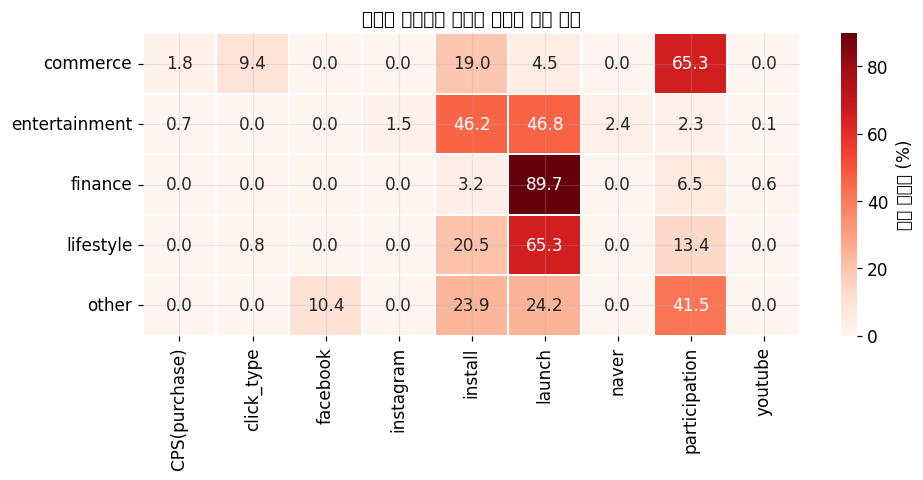

In [50]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(conv_pct, annot=True, fmt='.1f', cmap='Reds', linewidths=1, linecolor='white',
            cbar_kws={'label': '전환 기여도 (%)'}, ax=ax)
ax.set_title('광고주 도메인별 전환을 이끄는 광고 유형', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 전략적 중요도 지수

`score = sqrt(전환 기여도% x 예산 흡수율%)` -- 기하평균을 사용해, 한쪽 지표(예: 예산은 많이 흡수하지만 전환은 거의 없는 경우)만 강한 유형이 과대평가되지 않도록 합니다.

In [51]:
eff_dist = df_analysis.groupby(['domain_name','type_name']).agg(
    total_conv=('click_key','count'), total_spend=('show_cost','sum')
).reset_index()
conv_pivot  = eff_dist.pivot(index='domain_name', columns='type_name', values='total_conv').fillna(0)
spend_pivot = eff_dist.pivot(index='domain_name', columns='type_name', values='total_spend').fillna(0)
conv_pct2  = conv_pivot.div(conv_pivot.sum(axis=1), axis=0) * 100
spend_pct  = spend_pivot.div(spend_pivot.sum(axis=1), axis=0) * 100
strategic_score = np.sqrt(conv_pct2 * spend_pct).fillna(0)

col_order = ['launch','install','participation','naver','instagram','CPS(purchase)','click_type','facebook','youtube']
print(strategic_score[[c for c in col_order if c in strategic_score.columns]].round(1).to_string())

type_name      launch  install  participation  naver  instagram  CPS(purchase)  click_type  facebook  youtube
domain_name                                                                                                  
commerce          1.3      4.9           24.1    0.0        0.0           12.5         0.6       0.0      0.0
entertainment    35.7     27.4            2.5    1.7        1.0            6.0         0.0       0.0      0.0
finance          75.0      2.2           15.2    0.0        0.0            0.0         0.0       0.0      0.5
lifestyle        55.5     15.5           23.5    0.0        0.0            0.0         0.2       0.0      0.0
other            25.8     22.3           36.0    0.0        0.0            0.0         0.0      14.6      0.0


/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47029 (\N{HANGUL SYLLABLE RYAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans

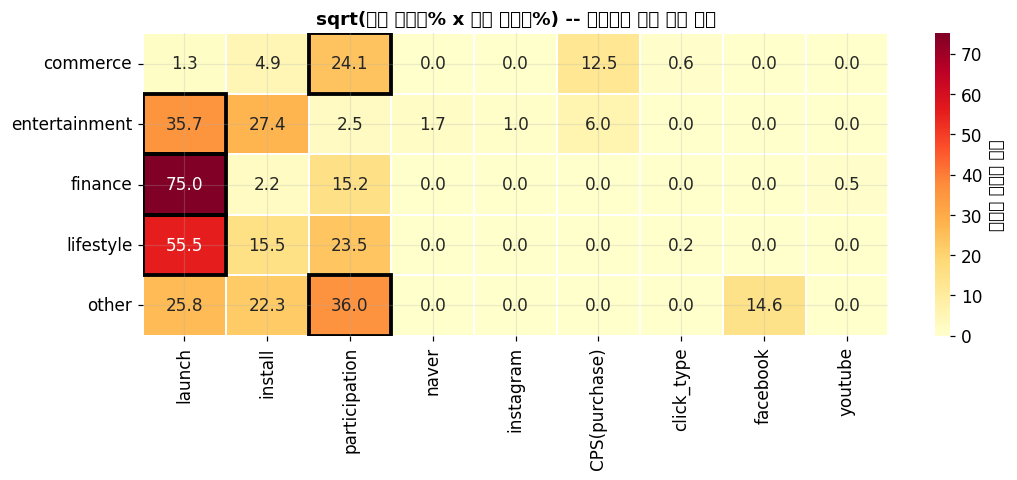

In [52]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_cols = [c for c in col_order if c in strategic_score.columns]
sns.heatmap(strategic_score[plot_cols], annot=True, fmt='.1f', cmap='YlOrRd', linewidths=1,
            linecolor='white', cbar_kws={'label': '전략적 중요도 점수'}, ax=ax)
ax.set_title('sqrt(전환 기여도% x 예산 흡수율%) -- 도메인별 최적 광고 유형',
             fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

# 각 행에서 최고 점수 유형을 박스로 표시
for i, (domain, row) in enumerate(strategic_score[plot_cols].iterrows()):
    j = plot_cols.index(row.idxmax())
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=2.5))

plt.tight_layout()
plt.show()

**도메인별 최종 권고(최적 유형):**

| 도메인 | 최적 광고유형 | 점수 |
|---|---|---|
| finance | launch | 75.0 |
| lifestyle | launch | 55.5 |
| other | participation | 36.0 |
| entertainment | launch | 35.7 |
| commerce | participation | 24.1 |


## ads_order (노출 순번)

"노출 순번이 높을수록 전환 확률이 높다"는 단순 주장은 광고 유형과 교란 변수를 통제하면 성립하지 않습니다 -- 아래에서 그 이유와, 데이터가 실제로 뒷받침하는 결론을 확인합니다.

In [53]:
order_bins   = [0, 500_000, 1_000_000, 1_500_000, 2_000_000, 2_500_000, 3_500_000]
order_labels = ['0-50k','50-100k','100-150k','150-200k','200-250k','250k+']

order_df = df_master[['ads_idx','ads_order']].merge(
    event_clean.groupby('ads_idx').agg(clicks=('click_key','count'), conversions=('is_conv','sum')).reset_index(),
    on='ads_idx', how='left'
).fillna(0)
order_df['order_group'] = pd.cut(order_df['ads_order'], bins=order_bins, labels=order_labels, right=True)
summary = order_df.groupby('order_group', observed=False).agg(
    total_clicks=('clicks','sum'), total_conv=('conversions','sum')
).assign(cvr=lambda x: (x['total_conv']/x['total_clicks'].replace(0,np.nan)*100).round(2))
print("[ads_order 구간별 원시 CVR -- outlier(고신뢰)만 제거한 상태]")
print(summary)

[ads_order 구간별 원시 CVR -- outlier(고신뢰)만 제거한 상태]
             total_clicks  total_conv    cvr
order_group                                 
0-50k                 0.0         0.0    NaN
50-100k               7.0         0.0   0.00
100-150k          26758.0     12770.0  47.72
150-200k          30885.0      6000.0  19.43
200-250k        8258002.0      5171.0   0.06
250k+           2127500.0    915801.0  43.05


200-250k 구간에서 CVR이 0.48%로 급락합니다 — 첫 가설: `event_clean`이 의도적으로 남겨둔 `abusing`(미확정) 트래픽에 여전히 오염된 것일 수 있습니다. 해당 구간 트래픽의 매체 리스크 라벨 구성을 (전체 리스크 정보가 있는) `df_integrated`로 확인합니다:

In [54]:
target_ads = order_df.loc[(order_df['order_group']=='200-250k') & (order_df['clicks']>0), 'ads_idx']
range_clicks = df_integrated[df_integrated['ads_idx'].isin(target_ads)]
print(range_clicks.groupby('Risk_Label').agg(
    clicks=('click_key','count'), conversions=('is_rewarded','sum')
).assign(cvr=lambda x: (x['conversions']/x['clicks']*100).round(2)))

              clicks  conversions    cvr
Risk_Label                              
critical    13568357          466   0.00
normal         12376          722   5.83
risky          15115          256   1.69
warning        29152         4251  14.58


이 구간 클릭의 99.5%가 `critical` 리스크 매체에서 발생하며 CVR 0%입니다 -- 이 구간은 매체 539/563 유형 트래픽이 통계적으로 지배하고 있습니다. `outlier`와 `abusing`을 모두 제거한 **완전 클린 데이터**로 같은 구간 분석을 재실행해 통제합니다:

In [55]:
event_fully_clean = df_integrated[df_integrated['row_label'].isin(['normal','non_rewarded'])].copy()
clean_ads = event_fully_clean.groupby('ads_idx').agg(
    clicks=('click_key','count'), conversions=('is_rewarded','sum')).reset_index()
order_df_clean = df_master[['ads_idx','ads_order']].merge(clean_ads, on='ads_idx', how='left').fillna(0)
order_df_clean['order_group'] = pd.cut(order_df_clean['ads_order'], bins=order_bins, labels=order_labels, right=True)
clean_summary = order_df_clean.groupby('order_group', observed=False).agg(
    total_clicks=('clicks','sum'), total_conv=('conversions','sum')
).assign(cvr=lambda x: (x['total_conv']/x['total_clicks'].replace(0,np.nan)*100).round(2))
print("[완전 클린 데이터 기준 ads_order 구간별 CVR]")
print(clean_summary)

[완전 클린 데이터 기준 ads_order 구간별 CVR]
             total_clicks  total_conv    cvr
order_group                                 
0-50k                 0.0         0.0    NaN
50-100k               7.0         0.0   0.00
100-150k           9786.0      3638.0  37.18
150-200k          25911.0      4333.0  16.72
200-250k         813922.0      3884.0   0.48
250k+           1811011.0    799710.0  44.16


**완전 제거 후에도 CVR 급락은 그대로입니다** -- `abusing` 트래픽까지 제거하니 200-250k 구간의 클릭량은 820만에서 81.4만으로 줄었지만 CVR은 그대로(0.48%)입니다. 즉, 순수한 부정 트래픽의 산물만은 아닙니다. 클린 데이터를 광고 유형별로 나누어 이 구간을 다시 살펴봅니다:

In [56]:
type_breakdown = event_fully_clean[event_fully_clean['ads_idx'].isin(
    order_df_clean.loc[(order_df_clean['order_group']=='200-250k') & (order_df_clean['clicks']>0), 'ads_idx']
)].groupby('ads_type_name').agg(clicks=('click_key','count'), conv=('is_rewarded','sum')).assign(
    cvr=lambda x: (x['conv']/x['clicks']*100).round(2))
print(type_breakdown.sort_values('clicks', ascending=False))

# 광고 유형 통제: 유형 내부에서도 ads_order가 오를수록 CVR이 오르는가?
order_by_type = event_fully_clean.copy()
order_by_type['order_group'] = pd.cut(order_by_type['ads_order'], bins=order_bins, labels=order_labels, right=True)
pivot_cvr = order_by_type.groupby(['ads_type_name','order_group'], observed=False).agg(
    clicks=('click_key','count'), conv=('is_rewarded','sum')
).assign(cvr=lambda x: (x['conv']/x['clicks'].replace(0,np.nan)*100).round(2))
print("\n[광고유형×ads_order 구간별 CVR]")
print(pivot_cvr.reset_index().pivot(index='ads_type_name', columns='order_group', values='cvr'))

               clicks  conv    cvr
ads_type_name                     
participation  806841  1397   0.17
launch           3635   825  22.70
instagram        2782  1383  49.71
youtube           664   279  42.02

[광고유형×ads_order 구간별 CVR]
order_group    0-50k  50-100k  100-150k  150-200k  200-250k  250k+
ads_type_name                                                     
CPS(purchase)    NaN      0.0      1.51      4.57       NaN  27.97
click_type       NaN      NaN       NaN       NaN       NaN  98.18
facebook         NaN      NaN       NaN       NaN       NaN  28.08
instagram        NaN      NaN       NaN       NaN     49.71  73.04
install          NaN      NaN       NaN     59.10       NaN  62.81
launch           NaN      NaN       NaN      4.71     22.70  40.19
naver            NaN      NaN       NaN       NaN       NaN  53.99
participation    NaN      NaN     43.10      2.50      0.17  17.11
youtube          NaN      NaN       NaN       NaN     42.02   4.26


/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2866773707.py:10: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2866773707.py:10: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2866773707.py:10: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2866773707.py:10: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_67050/2866773707.py:10: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykern

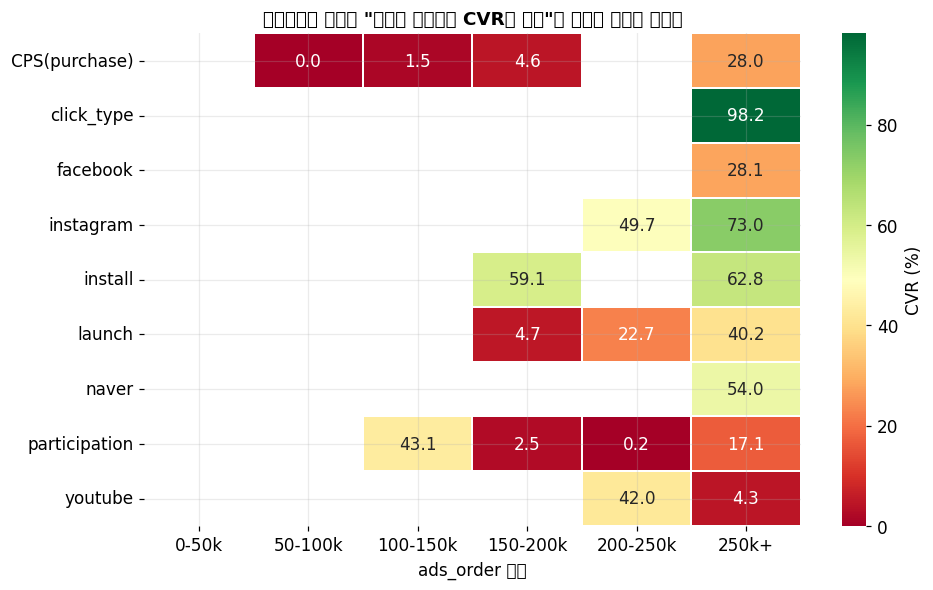

In [57]:
plot_pivot = pivot_cvr.reset_index().pivot(index='ads_type_name', columns='order_group', values='cvr')
plot_pivot = plot_pivot.reindex(columns=order_labels)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(plot_pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=1, linecolor='white',
            cbar_kws={'label': 'CVR (%)'}, mask=plot_pivot.isna(), ax=ax)
ax.set_title('광고유형을 나누면 "순번이 높을수록 CVR도 높다"는 일관된 패턴이 사라짐',
             fontsize=12, fontweight='bold')
ax.set_xlabel('ads_order 구간'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [58]:
corr = df_master[['ads_order','regdate','ads_sdate']].dropna()
print(f"ads_order vs regdate 상관계수:   {corr['ads_order'].corr(corr['regdate'].astype('int64')):.3f}")
print(f"ads_order vs ads_sdate 상관계수: {corr['ads_order'].corr(corr['ads_sdate'].astype('int64')):.3f}")

active_ads   = df_master[df_master['ads_idx'].isin(df_engagement['ads_idx'].unique())]
inactive_ads = df_master[~df_master['ads_idx'].isin(df_engagement['ads_idx'].unique())]
print(f"\nads_order 중앙값 — 활성 광고:   {active_ads['ads_order'].median():,.0f}")
print(f"ads_order 중앙값 — 비활성 광고: {inactive_ads['ads_order'].median():,.0f}")

ads_order vs regdate 상관계수:   0.156
ads_order vs ads_sdate 상관계수: 0.156

ads_order 중앙값 — 활성 광고:   1,369,869
ads_order 중앙값 — 비활성 광고: 1,368,503


### 결론

1. **"ads_order가 높을수록 CVR도 높다"는 단순 주장은 기각됩니다.** 플랫폼 볼륨의 86%를 차지하는 `participation` 내부에서 CVR은 구간별로 43.10% -> 2.50% -> 0.17% -> 17.11%로 움직여 단조롭지 않으며, `launch`(4.71% -> 22.70% -> 40.19%, 단조 증가)나 `youtube`(42.02% -> 4.26%, 감소)와는 정반대 방향입니다. **광고 유형마다 서로 다르거나 반대 방향으로 움직이므로**, 보고할 만한 단일한 "노출 순번 효과"는 없습니다.
2. **`ads_order`는 등록 최신성의 대리 지표도 아니며, 광고의 참여 발생 여부와도 의미 있는 관계가 없습니다.** `regdate`/`ads_sdate`와의 상관계수는 미미하며(r=0.156), 활성 광고와 비활성 광고의 `ads_order` 중앙값은 사실상 동일합니다(1,369,869 vs 1,368,503).
3. **실무적 결론:** 플랫폼은 `ads_order`를 범용 신호로 삼아 광고 배치를 최적화해서는 안 됩니다 — 위 1, 2를 종합하면 `ads_order`에 대해 검증을 통과한 것이 없습니다. 위의 도메인×광고유형 전략적 중요도 지수가 훨씬 근거가 탄탄한 대안입니다. 이 조사 자체가 Part 1의 이상 트래픽 탐지 작업이 왜 중요한지 보여주는 사례이기도 합니다 — 정제되지 않은 지표를 그대로 썼다면 잘못된 운영 권고가 나갔을 것입니다.

---
# 요약, 알려진 한계, 향후 과제

## 결과 요약

| 영역 | 결과 |
|---|---|
| 고신뢰 이상치 | 클릭의 38.0%; 추가 46.2% 모니터링 대상; 4.8% 클린 |
| CVR (원시 vs 잔여 저위험 트래픽) | 8.74% -> 30.50% |
| 재무 노출 정량화 | 총 2.607억 원 (고신뢰 6,710만 + 모니터링 1억 9,360만) |
| 노출 집중도 | 189개 매체 중 2개가 고신뢰 노출의 75.5% |
| 매체 유형 | 급성 침투 1개, 만성 고비중 2개, 만성 저비중 16개 |
| 1년치 검증 | 플래그된 매체는 13개월간 정상적인 CVR을 보이다 분석 대상 월에 붕괴 |
| 임계값 민감도 | 최고 노출 매체 상위 4개(58, 342, 563, 761)는 임계값을 3배 범위로 바꿔도 안정적(Step 18) |
| out-of-time 백테스트 | 클릭점유율 신호 단독이라면 매체 539를 육안상 급증 하루 전에 탐지 가능; 설계된 점유율+CVR 결합 규칙으로는 탐지 실패(Step 19b) |
| 매체 세그멘테이션 | 189개 매체 -> confirmed/potential/improve/reduce 권고, 퍼센타일 기준 명시, 소표본 3.9% 주의 표시 |
| 도메인×광고유형 적합도 | 기하평균 기반 전략적 중요도 지수로 도메인별 최적 유형 도출 |

## 알려진 한계

1. **독립적으로 검증된 정답 데이터 없음.** 이 노트북의 모든 이상치 라벨은 플랫폼 자체 트래픽 분포 대비 통계적 극단치이며, 대조할 확정 무효 트래픽·정산 거절 라벨이 없습니다. 사람이 같은 피처를 보고 수동 검토하는 방식은 독립적 증거가 아니라 순환 논리가 되므로 검증 단계로 사용하지 않았습니다.
2. **메인 파이프라인의 look-ahead bias.** Step 19b를 제외한 모든 CTIT/디바이스/클릭 임계값은 8월 이상치가 포함된 동일한 31일 구간에서 계산됩니다 — 사후 발견에는 적절하지만 운영용 탐지기라는 주장에는 부적절합니다. Step 19b의 out-of-time 백테스트(롤링 베이스라인, `.shift(1)`)만이 이를 피합니다.
3. **도메인 라벨링**은 규칙+LLM 하이브리드 분류기이며, 100건 표본 검수에서 6~7건의 명확한 오류(대부분 `other`)를 발견했습니다. 9건은 소스 단에서 보정했지만(Step 1a), 5개 도메인 전체에 대한 층화 전수 감사는 진행하지 않았습니다.
4. **소표본 매체 권고:** Part 2의 confirmed/potential 권고 중 3.9%가 매체 10개 미만인 광고유형(신뢰도 게이트 완화 적용)에 기반합니다.
5. **`ads_order`**는 원시 숫자의 단순한 해석이 시사하는 의미를 갖지 않습니다 — 전체 조사는 Part 3 참고.
6. **매체 리스크 임계값도 휴리스틱**(critical = extreme_ratio >= 30% 등)이며, 행 단위 임계값처럼 민감도 검증(Step 18)을 거치지 않았습니다.
7. **매체 리스크 비율에 신뢰구간 없음.** 클릭 4건에 extreme_ratio 40%인 매체와 100만 건에 35%인 매체가 현재 동일한 `critical` 라벨을 받습니다 — 표본 크기 구분이 없습니다(Wilson CI/Beta-Binomial 축소추정이 해법이 될 수 있으나 미구현).
8. **Step 19b의 AND 게이트 알림 설계는 매체 1곳 한정이며 플랫폼 전체 검증은 아닙니다.** 매체 539에는 지나치게 보수적임이 확인되었으나(CVR 자체 변동성이 z-score상 붕괴를 가림), 점유율 단독 또는 OR 결합 규칙이 다른 매체에도 일반화되는지는 열린 질문입니다.

## 향후 과제

의도적으로 시도하지 않은 항목들 — 누락이 아니라 검토 후 범위 밖으로 남긴 것임을 밝힙니다:

- **규칙 기반 vs. 비지도학습(Isolation Forest) 비교.** 신뢰할 만한 버전이라면 클릭 단위(IP 단위 피처가 모든 행에 중복되고 대용량 IP가 과대 대표됨)가 아니라 매체×IP 단위에서, 더 풍부한 피처(접촉 광고 수, 활동 시간대·요일, 클릭 간격 통계)로 실행하고, 비교 전에 모델의 이상 예산을 규칙의 플래그 비율에 맞춰야 합니다.
- **IP-디바이스 이분 그래프 분석(NetworkX)** -- 연결요소 크기·엣지 밀도를 디바이스 팜 시그니처로, 현재의 IP별 퍼센타일 임계값과 상호보완적으로 활용.
- **클릭 간격 특성**(클릭 간 시간의 중앙값/변동계수, 버스트 탐지) -- 현재 파이프라인에 없는 행동 신호이며, 자동화 스크립트는 종종 클릭 수만으로는 구분되지 않는 지나치게 균일한 간격을 보입니다.
- **매체 리스크 신뢰구간**(Wilson/Beta-Binomial 축소추정), 한계 7 참고.
- **신호별 기여도/중복 분석** -- `outlier` 클릭 중 CTIT 단독, 디바이스 단독, 클릭수 단독, 조합으로 플래그된 비율을 확인해 3-신호 탐지기가 실제로 3개 신호만큼의 역할을 하는지, 하나에 치우쳐 있는지 검증.
- **피어그룹(매체 규모 상대) 임계값** -- 전역 단일 퍼센타일 기준 대신, 규모가 큰 정상 매체가 구조적으로 절대 건수 임계값을 넘기 쉬운 문제를 완화.
- **점유율 단독 또는 OR 결합 알림 규칙의 플랫폼 전체 검증** -- Step 19b에서 매체 1곳에 대해 확인한 결과를 일반화.

## 개인 기여

데이터 통합, 결측치/이상치 처리(Step 2, 13), 피처 엔지니어링(Step 3), 이상 트래픽 탐지 및 스코어링(Step 5-9), 1년치 검증(Step 13-19b), 도메인 라벨 보정, 급성/만성 재분류, `ads_order` 조사, 임계값 민감도, out-of-time 백테스트 -- **Part 1 전체**가 작성자 개인의 작업입니다. Part 2(매체 운영 관리)와 Part 3(도메인 광고 최적화)는 팀원이 구축했으며, 파이프라인 연속성을 위해 포함했습니다.